# 08 — Targeted Frequency-Domain Sampling

## Goal

Test whether direct frequency-domain evaluation can reduce the number of
spectral points required to resolve a two-dimensional spectrum by using
nonuniform frequency grids concentrated in spectrally active regions.

The comparison will use a dense reference spectrum and equal sampling
budgets for uniform and targeted grids.

The targeted grid will be constructed from information obtained from an
initial coarse survey rather than from the dense reference spectrum.

In [1]:
# ------------------------------------------------------------
# Imports and physical constants
# ------------------------------------------------------------

import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pulsus


HBAR_EV_FS = 0.6582119569

# Baseline dimer parameters
E_center = 2.00       # eV
detuning = 0.040      # eV
J_baseline = 0.040    # eV

Ea = E_center - detuning / 2.0
Eb = E_center + detuning / 2.0

gamma_a = 0.020       # fs^-1
gamma_b = 0.020       # fs^-1

nbar_a = 0.0
nbar_b = 0.0

omega_L = (
    E_center
    / HBAR_EV_FS
)

T_fs = 100.0
eta = 1.0e-10

print("PULSUS imported successfully")
print(f"Ea = {Ea:.3f} eV")
print(f"Eb = {Eb:.3f} eV")
print(f"J  = {1000*J_baseline:.1f} meV")
print(f"omega_L = {omega_L:.6f} fs^-1")

PULSUS imported successfully
Ea = 1.980 eV
Eb = 2.020 eV
J  = 40.0 meV
omega_L = 3.038535 fs^-1


In [4]:
# ------------------------------------------------------------
# Import the dimer model helper from ../src
# ------------------------------------------------------------

import sys
from pathlib import Path
import inspect

src_dir = (
    Path.cwd().parent
    / "src"
)

if str(src_dir) not in sys.path:
    sys.path.insert(
        0,
        str(src_dir),
    )

from dimer_model import build_dimer

print(
    "build_dimer:",
    inspect.signature(
        build_dimer
    )
)

print(
    "SpectroscopySystem:",
    inspect.signature(
        pulsus.SpectroscopySystem
    )
)

build_dimer: (omega_a=1.0, omega_b=1.2, J=0.1, gamma_a=0.05, gamma_b=0.05, nbar_a=0.05, nbar_b=0.05, mu_a=1.0, mu_b=1.0, hbar=1.0)
SpectroscopySystem: (H, dipole, collapse_ops=None, rho0=None, hbar=1.0, dipole_plus=None, dipole_minus=None)


In [6]:
# ------------------------------------------------------------
# Build the baseline J = 40 meV spectroscopy system
# ------------------------------------------------------------

model = build_dimer(
    omega_a=Ea / HBAR_EV_FS,
    omega_b=Eb / HBAR_EV_FS,
    J=J_baseline / HBAR_EV_FS,
    gamma_a=gamma_a,
    gamma_b=gamma_b,
    nbar_a=nbar_a,
    nbar_b=nbar_b,
    hbar=HBAR_EV_FS,
)

mu_plus = (
    model["sigma_a_plus"]
    + model["sigma_b_plus"]
)

mu_minus = (
    model["sigma_a_minus"]
    + model["sigma_b_minus"]
)

collapse_ops = [
    model["L_a_down"],
    model["L_a_up"],
    model["L_b_down"],
    model["L_b_up"],
]

system = pulsus.SpectroscopySystem(
    H=model["H_S"],
    dipole=model["mu"],
    collapse_ops=collapse_ops,
    rho0=model["rho0"],
    hbar=HBAR_EV_FS,
    dipole_plus=mu_plus,
    dipole_minus=mu_minus,
)

print("Hilbert dimension:", system.d)
print("Liouville dimension:", system.d**2)

print(
    "Hamiltonian eigenvalues (eV):",
    np.linalg.eigvalsh(model["H_S"]),
)

print(
    "rho0 trace:",
    np.trace(model["rho0"]),
)

print(
    "||L rho0||:",
    np.linalg.norm(
        system.L @ model["rho0"].reshape(
            -1,
            order="F",
        )
    ),
)

Hilbert dimension: 4
Liouville dimension: 16
Hamiltonian eigenvalues (eV): [0.         1.95527864 2.04472136 4.        ]
rho0 trace: (1+0j)
||L rho0||: 0.0


In [7]:
# ------------------------------------------------------------
# Benchmark pulse for targeted frequency sampling
# ------------------------------------------------------------

intensity_fwhm = 20.0  # fs

sigma = (
    intensity_fwhm
    / (2.0 * np.sqrt(np.log(2.0)))
)

E0_pulse = (
    2.0
    / (
        np.sqrt(2.0 * np.pi)
        * sigma
    )
)

pulse = pulsus.GaussianPulse(
    omega_L=omega_L,
    sigma=sigma,
    E0=E0_pulse,
)

C = (
    (E0_pulse / 2.0)
    * np.sqrt(2.0 * np.pi)
    * sigma
)

print(f"Intensity FWHM = {intensity_fwhm:.2f} fs")
print(f"sigma = {sigma:.6f} fs")
print(f"E0 = {E0_pulse:.8f} fs^-1")
print(f"Gaussian prefactor C = {C:.12f}")

Intensity FWHM = 20.00 fs
sigma = 12.011224 fs
E0 = 0.06642825 fs^-1
Gaussian prefactor C = 1.000000000000


In [8]:
# ------------------------------------------------------------
# Dense reference spectrum
# Model A, nonrephasing branch
# ------------------------------------------------------------

E_min = 1.75
E_max = 2.25
n_reference = 641

E1_reference = np.linspace(
    E_min,
    E_max,
    n_reference,
)

E3_reference = np.linspace(
    E_min,
    E_max,
    n_reference,
)

omega1_reference = (
    E1_reference
    / HBAR_EV_FS
)

omega3_reference = (
    E3_reference
    / HBAR_EV_FS
)

t0 = time.perf_counter()

S_reference = pulsus.finite_pulse_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=omega1_reference,
    omega3=omega3_reference,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

reference_runtime = (
    time.perf_counter() - t0
)

dE_reference_meV = (
    1000.0
    * (E_max - E_min)
    / (n_reference - 1)
)

print("Dense NR reference")
print("------------------")
print(
    "shape:",
    S_reference.shape,
)
print(
    "frequency pairs:",
    S_reference.size,
)
print(
    f"dE = {dE_reference_meV:.5f} meV"
)
print(
    f"runtime = {reference_runtime:.4f} s"
)
print(
    f"max |S| = "
    f"{np.max(np.abs(S_reference)):.6e}"
)

Dense NR reference
------------------
shape: (641, 641)
frequency pairs: 410881
dE = 0.78125 meV
runtime = 0.1355 s
max |S| = 1.320786e+04


In [9]:
# ------------------------------------------------------------
# Stage 1: cheap coarse survey
# ------------------------------------------------------------

n_coarse = 21

E1_coarse = np.linspace(
    E_min,
    E_max,
    n_coarse,
)

E3_coarse = np.linspace(
    E_min,
    E_max,
    n_coarse,
)

omega1_coarse = (
    E1_coarse
    / HBAR_EV_FS
)

omega3_coarse = (
    E3_coarse
    / HBAR_EV_FS
)

t0 = time.perf_counter()

S_coarse = pulsus.finite_pulse_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=omega1_coarse,
    omega3=omega3_coarse,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

coarse_runtime = (
    time.perf_counter() - t0
)

S_coarse_norm = (
    np.abs(S_coarse)
    / np.max(np.abs(S_coarse))
)

print("Coarse survey")
print("-------------")
print(
    "shape:",
    S_coarse.shape,
)
print(
    "frequency pairs:",
    S_coarse.size,
)
print(
    f"runtime = {coarse_runtime:.6f} s"
)
print(
    f"coarse spacing = "
    f"{1000*(E_max-E_min)/(n_coarse-1):.2f} meV"
)

Coarse survey
-------------
shape: (21, 21)
frequency pairs: 441
runtime = 0.007970 s
coarse spacing = 25.00 meV


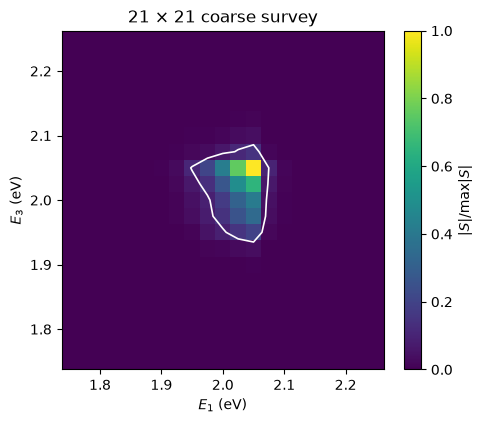

In [10]:
fig, ax = plt.subplots(
    figsize=(5.2, 4.4)
)

pcm = ax.pcolormesh(
    E1_coarse,
    E3_coarse,
    S_coarse_norm,
    shading="auto",
)

ax.contour(
    E1_coarse,
    E3_coarse,
    S_coarse_norm,
    levels=[0.10],
    colors="white",
    linewidths=1.2,
)

ax.set_xlabel(
    r"$E_1$ (eV)"
)

ax.set_ylabel(
    r"$E_3$ (eV)"
)

ax.set_title(
    "21 × 21 coarse survey"
)

fig.colorbar(
    pcm,
    ax=ax,
    label=r"$|S|/\max|S|$",
)

plt.show()

In [11]:
# ------------------------------------------------------------
# Identify the active spectral region from the coarse survey
# ------------------------------------------------------------

activity_threshold = 0.10

active_mask = (
    S_coarse_norm
    >= activity_threshold
)

active_rows, active_cols = np.where(
    active_mask
)

# Bounding indices of the active region
i3_min = active_rows.min()
i3_max = active_rows.max()

i1_min = active_cols.min()
i1_max = active_cols.max()

# Add one coarse-grid cell of padding on each side
padding = 1

i3_min_pad = max(
    0,
    i3_min - padding,
)

i3_max_pad = min(
    n_coarse - 1,
    i3_max + padding,
)

i1_min_pad = max(
    0,
    i1_min - padding,
)

i1_max_pad = min(
    n_coarse - 1,
    i1_max + padding,
)

E1_target_min = E1_coarse[
    i1_min_pad
]

E1_target_max = E1_coarse[
    i1_max_pad
]

E3_target_min = E3_coarse[
    i3_min_pad
]

E3_target_max = E3_coarse[
    i3_max_pad
]

print("Target region from coarse survey")
print("--------------------------------")
print(
    f"threshold = {100*activity_threshold:.0f}%"
)
print(
    f"E1 target = "
    f"{E1_target_min:.3f} to "
    f"{E1_target_max:.3f} eV"
)
print(
    f"E3 target = "
    f"{E3_target_min:.3f} to "
    f"{E3_target_max:.3f} eV"
)

print()
print(
    "Active coarse pixels:",
    np.count_nonzero(active_mask),
)

Target region from coarse survey
--------------------------------
threshold = 10%
E1 target = 1.925 to 2.075 eV
E3 target = 1.925 to 2.100 eV

Active coarse pixels: 19


In [12]:
# ------------------------------------------------------------
# Construct targeted nonuniform frequency axes
# ------------------------------------------------------------

def targeted_axis(
    E_min,
    E_max,
    target_min,
    target_max,
    n_total,
    target_fraction=0.70,
):
    """
    Construct a monotonic nonuniform axis with enhanced
    sampling inside a target interval.
    """

    n_target = int(
        round(
            target_fraction * n_total
        )
    )

    # Leave at least two points for each wing
    n_target = min(
        n_target,
        n_total - 4,
    )

    n_wings = (
        n_total - n_target
    )

    left_width = (
        target_min - E_min
    )

    right_width = (
        E_max - target_max
    )

    wing_width = (
        left_width + right_width
    )

    n_left = max(
        2,
        int(
            round(
                n_wings
                * left_width
                / wing_width
            )
        ),
    )

    n_right = (
        n_wings - n_left
    )

    if n_right < 2:
        n_right = 2
        n_left = n_wings - 2

    # Exclude shared boundaries from the wings
    left = np.linspace(
        E_min,
        target_min,
        n_left + 1,
        endpoint=True,
    )[:-1]

    center = np.linspace(
        target_min,
        target_max,
        n_target,
        endpoint=True,
    )

    right = np.linspace(
        target_max,
        E_max,
        n_right + 1,
        endpoint=True,
    )[1:]

    axis = np.concatenate(
        [
            left,
            center,
            right,
        ]
    )

    return axis


n_test = 61

E1_targeted = targeted_axis(
    E_min,
    E_max,
    E1_target_min,
    E1_target_max,
    n_test,
)

E3_targeted = targeted_axis(
    E_min,
    E_max,
    E3_target_min,
    E3_target_max,
    n_test,
)

E1_uniform = np.linspace(
    E_min,
    E_max,
    n_test,
)

E3_uniform = np.linspace(
    E_min,
    E_max,
    n_test,
)

print("Axis sizes")
print("----------")
print(
    "uniform:",
    len(E1_uniform),
    len(E3_uniform),
)
print(
    "targeted:",
    len(E1_targeted),
    len(E3_targeted),
)

print()
print("Approximate spacings")

print(
    f"Uniform = "
    f"{1000*np.diff(E1_uniform).mean():.3f} meV"
)

mask_E1 = (
    (E1_targeted >= E1_target_min)
    & (E1_targeted <= E1_target_max)
)

mask_E3 = (
    (E3_targeted >= E3_target_min)
    & (E3_targeted <= E3_target_max)
)

print(
    f"Targeted E1 active region = "
    f"{1000*np.diff(E1_targeted[mask_E1]).mean():.3f} meV"
)

print(
    f"Targeted E3 active region = "
    f"{1000*np.diff(E3_targeted[mask_E3]).mean():.3f} meV"
)

Axis sizes
----------
uniform: 61 61
targeted: 61 61

Approximate spacings
Uniform = 8.333 meV
Targeted E1 active region = 3.571 meV
Targeted E3 active region = 4.167 meV


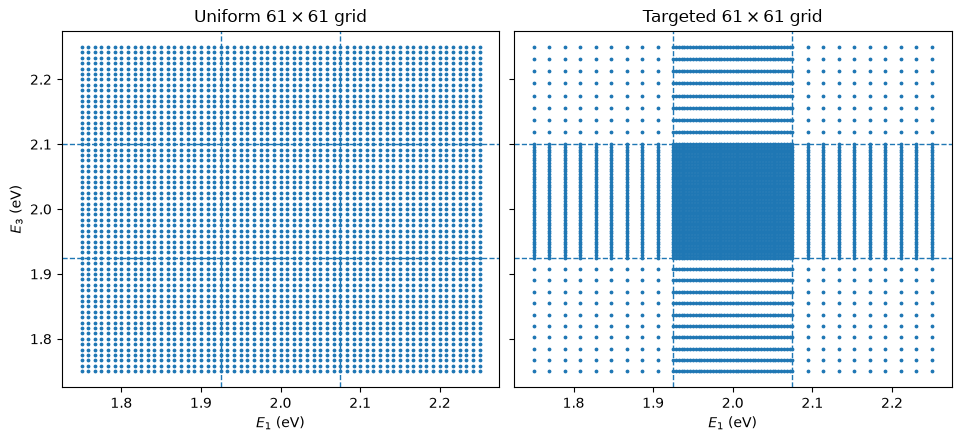

In [13]:
# ------------------------------------------------------------
# Visualize uniform vs targeted sampling grids
# ------------------------------------------------------------

E1u_mesh, E3u_mesh = np.meshgrid(
    E1_uniform,
    E3_uniform,
)

E1t_mesh, E3t_mesh = np.meshgrid(
    E1_targeted,
    E3_targeted,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.5, 4.3),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes[0].scatter(
    E1u_mesh.ravel(),
    E3u_mesh.ravel(),
    s=3,
)

axes[0].set_title(
    r"Uniform $61\times61$ grid"
)

axes[1].scatter(
    E1t_mesh.ravel(),
    E3t_mesh.ravel(),
    s=3,
)

axes[1].set_title(
    r"Targeted $61\times61$ grid"
)

# Show the refinement region inferred from the coarse survey
for ax in axes:

    ax.axvline(
        E1_target_min,
        linestyle="--",
        linewidth=1.0,
    )

    ax.axvline(
        E1_target_max,
        linestyle="--",
        linewidth=1.0,
    )

    ax.axhline(
        E3_target_min,
        linestyle="--",
        linewidth=1.0,
    )

    ax.axhline(
        E3_target_max,
        linestyle="--",
        linewidth=1.0,
    )

    ax.set_xlabel(
        r"$E_1$ (eV)"
    )

axes[0].set_ylabel(
    r"$E_3$ (eV)"
)

plt.show()

In [14]:
# ------------------------------------------------------------
# Evaluate uniform and targeted 61 x 61 spectra
# ------------------------------------------------------------

# Uniform grid
t0 = time.perf_counter()

S_uniform = pulsus.finite_pulse_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=E1_uniform / HBAR_EV_FS,
    omega3=E3_uniform / HBAR_EV_FS,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

runtime_uniform = (
    time.perf_counter() - t0
)


# Targeted grid
t0 = time.perf_counter()

S_targeted = pulsus.finite_pulse_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=E1_targeted / HBAR_EV_FS,
    omega3=E3_targeted / HBAR_EV_FS,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

runtime_targeted = (
    time.perf_counter() - t0
)


print("Direct calculations")
print("-------------------")

print(
    f"Uniform:  {S_uniform.size:5d} pairs   "
    f"{runtime_uniform:.6f} s"
)

print(
    f"Targeted: {S_targeted.size:5d} pairs   "
    f"{runtime_targeted:.6f} s"
)

Direct calculations
-------------------
Uniform:   3721 pairs   0.025077 s
Targeted:  3721 pairs   0.013467 s


In [15]:
# ------------------------------------------------------------
# Interpolate both sampled spectra onto the dense reference grid
# ------------------------------------------------------------

from scipy.interpolate import RegularGridInterpolator


def interpolate_complex_spectrum(
    E1_source,
    E3_source,
    S_source,
    E1_destination,
    E3_destination,
):
    """
    Interpolate a complex spectrum defined on a rectangular,
    possibly nonuniform, Cartesian grid.
    """

    interp_real = RegularGridInterpolator(
        (E3_source, E1_source),
        np.real(S_source),
        method="linear",
        bounds_error=False,
        fill_value=None,
    )

    interp_imag = RegularGridInterpolator(
        (E3_source, E1_source),
        np.imag(S_source),
        method="linear",
        bounds_error=False,
        fill_value=None,
    )

    E1_mesh, E3_mesh = np.meshgrid(
        E1_destination,
        E3_destination,
    )

    points = np.column_stack(
        [
            E3_mesh.ravel(),
            E1_mesh.ravel(),
        ]
    )

    reconstructed = (
        interp_real(points)
        + 1j * interp_imag(points)
    )

    return reconstructed.reshape(
        E3_mesh.shape
    )


S_uniform_interp = interpolate_complex_spectrum(
    E1_uniform,
    E3_uniform,
    S_uniform,
    E1_reference,
    E3_reference,
)

S_targeted_interp = interpolate_complex_spectrum(
    E1_targeted,
    E3_targeted,
    S_targeted,
    E1_reference,
    E3_reference,
)

In [16]:
# ------------------------------------------------------------
# Reconstruction errors
# ------------------------------------------------------------

def relative_frobenius_error(
    approx,
    reference,
    mask=None,
):
    if mask is None:
        approx_i = approx
        reference_i = reference
    else:
        approx_i = approx[mask]
        reference_i = reference[mask]

    return (
        np.linalg.norm(
            approx_i - reference_i
        )
        / np.linalg.norm(
            reference_i
        )
    )


# Global error over the full 1.75-2.25 eV square
error_uniform_global = (
    relative_frobenius_error(
        S_uniform_interp,
        S_reference,
    )
)

error_targeted_global = (
    relative_frobenius_error(
        S_targeted_interp,
        S_reference,
    )
)


# Target-region error
E1_ref_mesh, E3_ref_mesh = np.meshgrid(
    E1_reference,
    E3_reference,
)

target_mask = (
    (E1_ref_mesh >= E1_target_min)
    & (E1_ref_mesh <= E1_target_max)
    & (E3_ref_mesh >= E3_target_min)
    & (E3_ref_mesh <= E3_target_max)
)

error_uniform_target = (
    relative_frobenius_error(
        S_uniform_interp,
        S_reference,
        mask=target_mask,
    )
)

error_targeted_target = (
    relative_frobenius_error(
        S_targeted_interp,
        S_reference,
        mask=target_mask,
    )
)


print("Reconstruction error")
print("--------------------")

print(
    f"Uniform global:   "
    f"{100*error_uniform_global:.4f}%"
)

print(
    f"Targeted global:  "
    f"{100*error_targeted_global:.4f}%"
)

print()

print(
    f"Uniform target:   "
    f"{100*error_uniform_target:.4f}%"
)

print(
    f"Targeted target:  "
    f"{100*error_targeted_target:.4f}%"
)

Reconstruction error
--------------------
Uniform global:   19.7308%
Targeted global:  5.1899%

Uniform target:   19.7394%
Targeted target:  5.1494%


In [17]:
# ------------------------------------------------------------
# Arbitrary scattered 2D frequency-coordinate evaluator
# ------------------------------------------------------------

def finite_pulse_point_cloud(
    system,
    pulse,
    E1_points,
    E3_points,
    T,
    eta,
    pathway="NR",
):
    """
    Evaluate Model A directly at arbitrary scattered
    (E1, E3) spectral coordinates.

    E1_points and E3_points must have the same length.
    """

    E1_points = np.asarray(
        E1_points,
        dtype=float,
    )

    E3_points = np.asarray(
        E3_points,
        dtype=float,
    )

    if E1_points.shape != E3_points.shape:
        raise ValueError(
            "E1_points and E3_points must have the same shape."
        )

    values = np.empty(
        E1_points.size,
        dtype=complex,
    )

    for k, (E1_i, E3_i) in enumerate(
        zip(
            E1_points.ravel(),
            E3_points.ravel(),
        )
    ):

        omega1_i = np.array([
            E1_i / HBAR_EV_FS
        ])

        omega3_i = np.array([
            E3_i / HBAR_EV_FS
        ])

        S_i = pulsus.finite_pulse_spectrum(
            system=system,
            pulse1=pulse,
            pulse2=pulse,
            pulse3=pulse,
            omega1=omega1_i,
            omega3=omega3_i,
            T=T,
            eta=eta,
            pathway=pathway,
        )

        values[k] = S_i[0, 0]

    return values.reshape(
        E1_points.shape
    )

In [18]:
# ------------------------------------------------------------
# Verify arbitrary-coordinate evaluation against grid output
# ------------------------------------------------------------

test_indices = [
    (5, 7),
    (13, 22),
    (27, 31),
    (42, 18),
    (55, 50),
]

E1_test = np.array([
    E1_uniform[j]
    for i, j in test_indices
])

E3_test = np.array([
    E3_uniform[i]
    for i, j in test_indices
])

S_cloud_test = finite_pulse_point_cloud(
    system=system,
    pulse=pulse,
    E1_points=E1_test,
    E3_points=E3_test,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

S_grid_test = np.array([
    S_uniform[i, j]
    for i, j in test_indices
])

relative_difference = (
    np.linalg.norm(
        S_cloud_test - S_grid_test
    )
    / np.linalg.norm(
        S_grid_test
    )
)

print("Arbitrary-coordinate verification")
print("---------------------------------")

for k in range(len(E1_test)):

    print(
        f"({E1_test[k]:.6f}, "
        f"{E3_test[k]:.6f}) eV   "
        f"|cloud-grid| = "
        f"{abs(S_cloud_test[k]-S_grid_test[k]):.3e}"
    )

print()
print(
    "Relative difference:",
    f"{relative_difference:.3e}"
)

Arbitrary-coordinate verification
---------------------------------
(1.808333, 1.791667) eV   |cloud-grid| = 2.995e-22
(1.933333, 1.858333) eV   |cloud-grid| = 2.831e-16
(2.008333, 1.975000) eV   |cloud-grid| = 2.842e-14
(1.900000, 2.100000) eV   |cloud-grid| = 1.343e-15
(2.166667, 2.208333) eV   |cloud-grid| = 1.071e-20

Relative difference: 2.773e-17


In [19]:
# ------------------------------------------------------------
# Construct an adaptive scattered 2D point cloud
# from the coarse survey only
# ------------------------------------------------------------

from scipy.interpolate import RegularGridInterpolator
from scipy.stats import qmc

n_cloud = n_test**2          # 3721 points
n_candidates = 50000

# Interpolate the coarse-survey activity.
activity_interp = RegularGridInterpolator(
    (E3_coarse, E1_coarse),
    S_coarse_norm,
    method="linear",
    bounds_error=False,
    fill_value=0.0,
)

# Start from a low-discrepancy candidate cloud over the full window.
sobol = qmc.Sobol(
    d=2,
    scramble=True,
    seed=12345,
)

candidate_unit = sobol.random(
    n_candidates
)

E1_candidates = (
    E_min
    + (E_max - E_min)
    * candidate_unit[:, 0]
)

E3_candidates = (
    E_min
    + (E_max - E_min)
    * candidate_unit[:, 1]
)

candidate_points = np.column_stack([
    E3_candidates,
    E1_candidates,
])

candidate_activity = activity_interp(
    candidate_points
)

# Importance weights:
# - nonzero floor preserves global coverage
# - coarse signal concentrates points in the active region
background_floor = 0.03
activity_power = 1.5

weights = (
    background_floor
    + candidate_activity**activity_power
)

weights = (
    weights
    / weights.sum()
)

# Fixed RNG makes the cloud reproducible.
rng = np.random.default_rng(
    20261008
)

selected = rng.choice(
    n_candidates,
    size=n_cloud,
    replace=False,
    p=weights,
)

E1_cloud = E1_candidates[
    selected
]

E3_cloud = E3_candidates[
    selected
]

print("Adaptive point cloud")
print("--------------------")
print(
    "points:",
    len(E1_cloud),
)

inside_target = (
    (E1_cloud >= E1_target_min)
    & (E1_cloud <= E1_target_max)
    & (E3_cloud >= E3_target_min)
    & (E3_cloud <= E3_target_max)
)

print(
    "points inside target region:",
    np.count_nonzero(inside_target),
)

print(
    "fraction inside target region:",
    f"{100*np.mean(inside_target):.2f}%"
)

Adaptive point cloud
--------------------
points: 3721
points inside target region: 1022
fraction inside target region: 27.47%


/var/folders/48/7yf2h_qd2hnfgnx8vt9t3b_h0000gn/T/ipykernel_88259/393213829.py:28: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  candidate_unit = sobol.random(


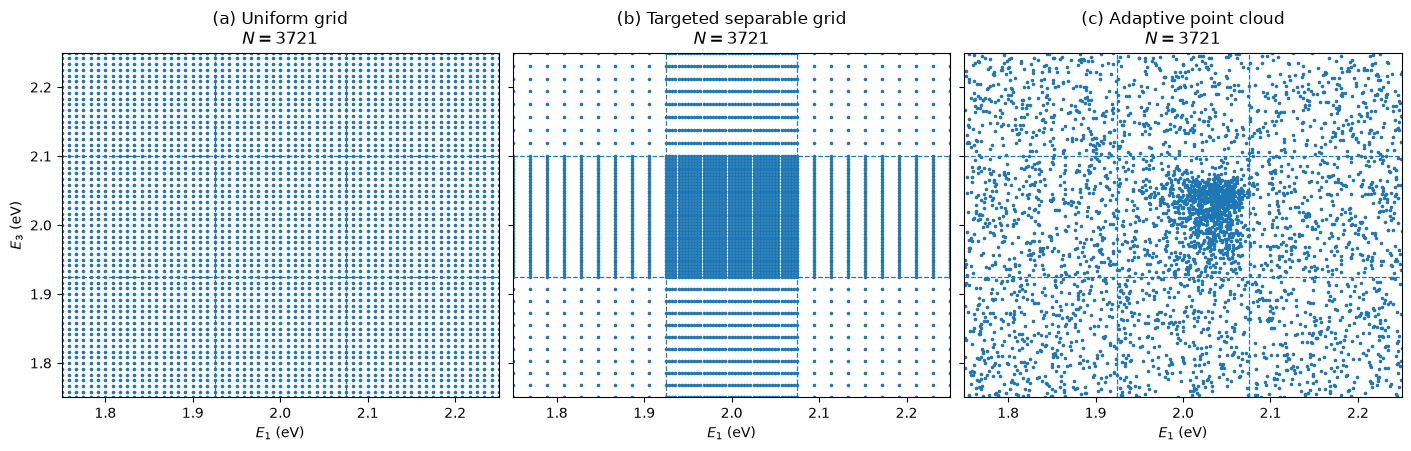

In [20]:
# ------------------------------------------------------------
# Compare the three sampling strategies
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14.0, 4.4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

# ------------------------------------------------------------
# (a) Uniform Cartesian grid
# ------------------------------------------------------------

axes[0].scatter(
    E1u_mesh.ravel(),
    E3u_mesh.ravel(),
    s=2.5,
)

axes[0].set_title(
    rf"(a) Uniform grid"
    "\n"
    rf"$N={E1u_mesh.size}$"
)

# ------------------------------------------------------------
# (b) Targeted separable Cartesian grid
# ------------------------------------------------------------

axes[1].scatter(
    E1t_mesh.ravel(),
    E3t_mesh.ravel(),
    s=2.5,
)

axes[1].set_title(
    rf"(b) Targeted separable grid"
    "\n"
    rf"$N={E1t_mesh.size}$"
)

# ------------------------------------------------------------
# (c) Adaptive scattered point cloud
# ------------------------------------------------------------

axes[2].scatter(
    E1_cloud,
    E3_cloud,
    s=2.5,
)

axes[2].set_title(
    rf"(c) Adaptive point cloud"
    "\n"
    rf"$N={len(E1_cloud)}$"
)

# Target region inferred solely from coarse survey
for ax in axes:

    ax.axvline(
        E1_target_min,
        linestyle="--",
        linewidth=0.9,
    )

    ax.axvline(
        E1_target_max,
        linestyle="--",
        linewidth=0.9,
    )

    ax.axhline(
        E3_target_min,
        linestyle="--",
        linewidth=0.9,
    )

    ax.axhline(
        E3_target_max,
        linestyle="--",
        linewidth=0.9,
    )

    ax.set_xlim(
        E_min,
        E_max,
    )

    ax.set_ylim(
        E_min,
        E_max,
    )

    ax.set_xlabel(
        r"$E_1$ (eV)"
    )

axes[0].set_ylabel(
    r"$E_3$ (eV)"
)

plt.show()

In [21]:
# ------------------------------------------------------------
# Structured adaptive 2D point cloud
#
# Coarse sampling over the full window, but coarse points
# inside the target region are replaced by a dense local patch.
# ------------------------------------------------------------

N_budget = 61**2
n_background = 21

# Coarse global background
E1_background_axis = np.linspace(
    E_min,
    E_max,
    n_background,
)

E3_background_axis = np.linspace(
    E_min,
    E_max,
    n_background,
)

E1_bg_mesh, E3_bg_mesh = np.meshgrid(
    E1_background_axis,
    E3_background_axis,
)

E1_bg_all = E1_bg_mesh.ravel()
E3_bg_all = E3_bg_mesh.ravel()

# Remove coarse points that lie inside the refinement rectangle.
inside_refinement_bg = (
    (E1_bg_all >= E1_target_min)
    & (E1_bg_all <= E1_target_max)
    & (E3_bg_all >= E3_target_min)
    & (E3_bg_all <= E3_target_max)
)

E1_background = E1_bg_all[
    ~inside_refinement_bg
]

E3_background = E3_bg_all[
    ~inside_refinement_bg
]

N_background = len(
    E1_background
)

# ------------------------------------------------------------
# Choose dense-patch dimensions automatically.
#
# We want approximately the same total number of points as
# the 61 x 61 uniform/separable calculations while maintaining
# approximately equal E1/E3 spacing inside the rectangular patch.
# ------------------------------------------------------------

target_width_E1 = (
    E1_target_max
    - E1_target_min
)

target_width_E3 = (
    E3_target_max
    - E3_target_min
)

best = None

for n1_patch in range(
    10,
    150,
):

    for n3_patch in range(
        10,
        150,
    ):

        N_total_i = (
            N_background
            + n1_patch * n3_patch
        )

        dE1_i = (
            target_width_E1
            / (n1_patch - 1)
        )

        dE3_i = (
            target_width_E3
            / (n3_patch - 1)
        )

        # Prefer:
        # 1. point count close to requested budget
        # 2. similar local resolution in E1 and E3
        budget_penalty = abs(
            N_total_i
            - N_budget
        )

        spacing_penalty = (
            abs(
                np.log(
                    dE1_i / dE3_i
                )
            )
        )

        score = (
            budget_penalty
            + 5.0 * spacing_penalty
        )

        if (
            best is None
            or score < best[0]
        ):
            best = (
                score,
                n1_patch,
                n3_patch,
                N_total_i,
            )

_, n1_patch, n3_patch, _ = best

# Dense local patch
E1_patch_axis = np.linspace(
    E1_target_min,
    E1_target_max,
    n1_patch,
)

E3_patch_axis = np.linspace(
    E3_target_min,
    E3_target_max,
    n3_patch,
)

E1_patch_mesh, E3_patch_mesh = np.meshgrid(
    E1_patch_axis,
    E3_patch_axis,
)

E1_patch = E1_patch_mesh.ravel()
E3_patch = E3_patch_mesh.ravel()

# Full structured point cloud
E1_structured = np.concatenate(
    [
        E1_background,
        E1_patch,
    ]
)

E3_structured = np.concatenate(
    [
        E3_background,
        E3_patch,
    ]
)

N_structured = len(
    E1_structured
)

print("Structured adaptive point cloud")
print("--------------------------------")

print(
    f"coarse background points = "
    f"{N_background}"
)

print(
    f"dense patch = "
    f"{n1_patch} x {n3_patch}"
)

print(
    f"dense patch points = "
    f"{n1_patch*n3_patch}"
)

print(
    f"total points = "
    f"{N_structured}"
)

print(
    f"requested comparison budget = "
    f"{N_budget}"
)

print(
    f"budget difference = "
    f"{N_structured-N_budget:+d}"
)

print()

print(
    f"local dE1 = "
    f"{1000*np.diff(E1_patch_axis).mean():.3f} meV"
)

print(
    f"local dE3 = "
    f"{1000*np.diff(E3_patch_axis).mean():.3f} meV"
)

Structured adaptive point cloud
--------------------------------
coarse background points = 385
dense patch = 47 x 71
dense patch points = 3337
total points = 3722
requested comparison budget = 3721
budget difference = +1

local dE1 = 3.261 meV
local dE3 = 2.500 meV


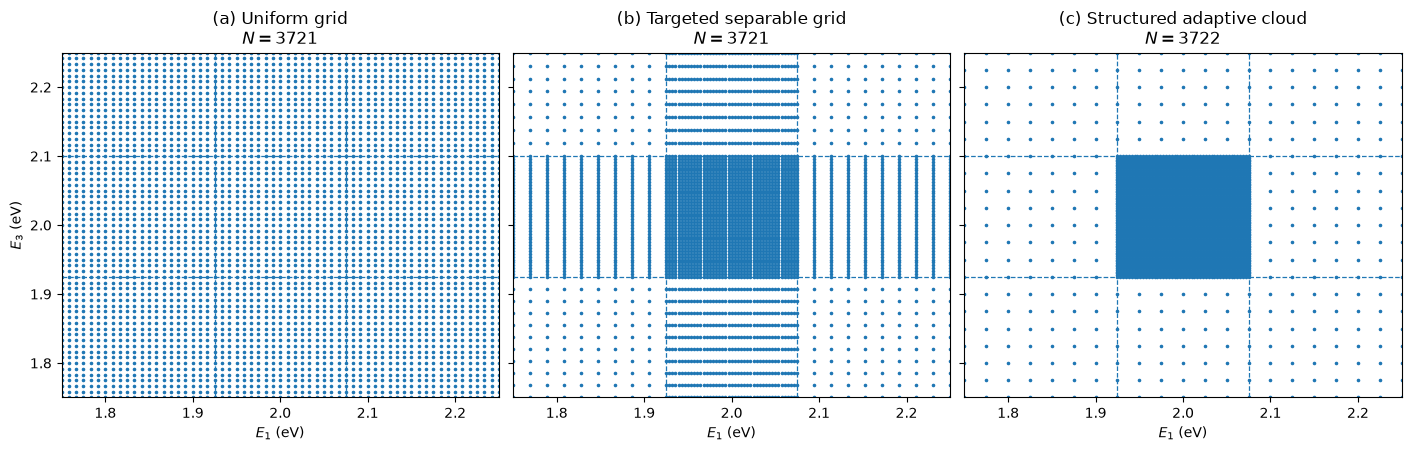

In [22]:
# ------------------------------------------------------------
# Uniform vs separable-targeted vs structured adaptive cloud
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14.0, 4.4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

# Uniform
axes[0].scatter(
    E1u_mesh.ravel(),
    E3u_mesh.ravel(),
    s=2.5,
)

axes[0].set_title(
    rf"(a) Uniform grid"
    "\n"
    rf"$N={E1u_mesh.size}$"
)

# Targeted separable
axes[1].scatter(
    E1t_mesh.ravel(),
    E3t_mesh.ravel(),
    s=2.5,
)

axes[1].set_title(
    rf"(b) Targeted separable grid"
    "\n"
    rf"$N={E1t_mesh.size}$"
)

# Structured adaptive cloud
axes[2].scatter(
    E1_structured,
    E3_structured,
    s=2.5,
)

axes[2].set_title(
    rf"(c) Structured adaptive cloud"
    "\n"
    rf"$N={N_structured}$"
)

for ax in axes:

    ax.axvline(
        E1_target_min,
        linestyle="--",
        linewidth=0.9,
    )

    ax.axvline(
        E1_target_max,
        linestyle="--",
        linewidth=0.9,
    )

    ax.axhline(
        E3_target_min,
        linestyle="--",
        linewidth=0.9,
    )

    ax.axhline(
        E3_target_max,
        linestyle="--",
        linewidth=0.9,
    )

    ax.set_xlim(
        E_min,
        E_max,
    )

    ax.set_ylim(
        E_min,
        E_max,
    )

    ax.set_xlabel(
        r"$E_1$ (eV)"
    )

axes[0].set_ylabel(
    r"$E_3$ (eV)"
)

plt.show()

In [23]:
# ------------------------------------------------------------
# Evaluate Model A on the structured adaptive point cloud
# ------------------------------------------------------------

t0 = time.perf_counter()

S_structured = finite_pulse_point_cloud(
    system=system,
    pulse=pulse,
    E1_points=E1_structured,
    E3_points=E3_structured,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

runtime_structured = (
    time.perf_counter() - t0
)

print("Structured adaptive calculation")
print("-------------------------------")
print(
    f"points = {len(S_structured)}"
)
print(
    f"runtime = {runtime_structured:.6f} s"
)

Structured adaptive calculation
-------------------------------
points = 3722
runtime = 0.751529 s


In [24]:
# ------------------------------------------------------------
# Common scattered-data interpolation for all three strategies
# ------------------------------------------------------------

from scipy.interpolate import LinearNDInterpolator


def reconstruct_scattered(
    E1_samples,
    E3_samples,
    S_samples,
    E1_destination,
    E3_destination,
):
    points = np.column_stack(
        [
            E1_samples,
            E3_samples,
        ]
    )

    interp_real = LinearNDInterpolator(
        points,
        np.real(S_samples),
    )

    interp_imag = LinearNDInterpolator(
        points,
        np.imag(S_samples),
    )

    E1_mesh, E3_mesh = np.meshgrid(
        E1_destination,
        E3_destination,
    )

    destination = np.column_stack(
        [
            E1_mesh.ravel(),
            E3_mesh.ravel(),
        ]
    )

    reconstructed = (
        interp_real(destination)
        + 1j * interp_imag(destination)
    )

    return reconstructed.reshape(
        E1_mesh.shape
    )


# Uniform
S_uniform_common = reconstruct_scattered(
    E1u_mesh.ravel(),
    E3u_mesh.ravel(),
    S_uniform.ravel(),
    E1_reference,
    E3_reference,
)

# Targeted separable
S_targeted_common = reconstruct_scattered(
    E1t_mesh.ravel(),
    E3t_mesh.ravel(),
    S_targeted.ravel(),
    E1_reference,
    E3_reference,
)

# Structured adaptive cloud
S_structured_common = reconstruct_scattered(
    E1_structured,
    E3_structured,
    S_structured,
    E1_reference,
    E3_reference,
)

In [25]:
# ------------------------------------------------------------
# Fair reconstruction-error comparison
# ------------------------------------------------------------

print("NaN counts")
print("----------")
print(
    "uniform:   ",
    np.count_nonzero(
        ~np.isfinite(S_uniform_common)
    ),
)
print(
    "targeted:  ",
    np.count_nonzero(
        ~np.isfinite(S_targeted_common)
    ),
)
print(
    "structured:",
    np.count_nonzero(
        ~np.isfinite(S_structured_common)
    ),
)

print()


strategies = {
    "Uniform": S_uniform_common,
    "Targeted separable": S_targeted_common,
    "Structured cloud": S_structured_common,
}

print("Common-interpolation reconstruction errors")
print("------------------------------------------")

for name, spectrum in strategies.items():

    err_global = relative_frobenius_error(
        spectrum,
        S_reference,
    )

    err_target = relative_frobenius_error(
        spectrum,
        S_reference,
        mask=target_mask,
    )

    print(
        f"{name:20s}  "
        f"global = {100*err_global:8.4f}%   "
        f"target = {100*err_target:8.4f}%"
    )

NaN counts
----------
uniform:    0
targeted:   0
structured: 0

Common-interpolation reconstruction errors
------------------------------------------
Uniform               global =  21.2646%   target =  21.2749%
Targeted separable    global =   5.4261%   target =   5.3820%
Structured cloud      global =   3.5070%   target =   3.2724%


In [26]:
# ------------------------------------------------------------
# Utilities for fair adaptive-sampling budgets
# ------------------------------------------------------------

def merge_unique_samples(
    E1_a,
    E3_a,
    S_a,
    E1_b,
    E3_b,
    S_b,
    decimals=12,
):
    """
    Merge two sets of scattered spectral samples and remove
    duplicate coordinates.

    The first occurrence is retained.
    """

    E1_all = np.concatenate([
        np.asarray(E1_a).ravel(),
        np.asarray(E1_b).ravel(),
    ])

    E3_all = np.concatenate([
        np.asarray(E3_a).ravel(),
        np.asarray(E3_b).ravel(),
    ])

    S_all = np.concatenate([
        np.asarray(S_a).ravel(),
        np.asarray(S_b).ravel(),
    ])

    keys = np.column_stack([
        np.round(E1_all, decimals),
        np.round(E3_all, decimals),
    ])

    _, unique_indices = np.unique(
        keys,
        axis=0,
        return_index=True,
    )

    unique_indices = np.sort(
        unique_indices
    )

    return (
        E1_all[unique_indices],
        E3_all[unique_indices],
        S_all[unique_indices],
    )


def structured_patch_dimensions(
    n_patch_requested,
):
    """
    Choose patch dimensions with approximately equal physical
    spacing along E1 and E3.
    """

    aspect = (
        (E1_target_max - E1_target_min)
        / (E3_target_max - E3_target_min)
    )

    n1 = max(
        2,
        int(
            round(
                np.sqrt(
                    n_patch_requested
                    * aspect
                )
            )
        ),
    )

    n3 = max(
        2,
        int(
            round(
                n_patch_requested
                / n1
            )
        ),
    )

    return n1, n3


def build_structured_refinement(
    total_budget,
):
    """
    Build a dense rectangular patch using the remaining budget
    after the 21x21 coarse survey.
    """

    remaining = max(
        4,
        total_budget - S_coarse.size,
    )

    n1_patch, n3_patch = (
        structured_patch_dimensions(
            remaining
        )
    )

    E1_patch_axis = np.linspace(
        E1_target_min,
        E1_target_max,
        n1_patch,
    )

    E3_patch_axis = np.linspace(
        E3_target_min,
        E3_target_max,
        n3_patch,
    )

    E1_patch_mesh, E3_patch_mesh = np.meshgrid(
        E1_patch_axis,
        E3_patch_axis,
    )

    return (
        E1_patch_mesh.ravel(),
        E3_patch_mesh.ravel(),
        n1_patch,
        n3_patch,
    )

In [27]:
test_budget = 1600

(
    E1_patch_test,
    E3_patch_test,
    n1_patch_test,
    n3_patch_test,
) = build_structured_refinement(
    test_budget
)

print("Budget test")
print("-----------")
print(
    f"requested total budget = {test_budget}"
)
print(
    f"coarse survey = {S_coarse.size}"
)
print(
    f"patch = "
    f"{n1_patch_test} x {n3_patch_test}"
)
print(
    f"raw patch points = "
    f"{len(E1_patch_test)}"
)
print(
    f"survey + raw patch = "
    f"{S_coarse.size + len(E1_patch_test)}"
)

Budget test
-----------
requested total budget = 1600
coarse survey = 441
patch = 32 x 36
raw patch points = 1152
survey + raw patch = 1593


In [28]:
# ------------------------------------------------------------
# One complete comparison at total budget ~1600
# ------------------------------------------------------------

budget_test = 1600

# ============================================================
# 1. Uniform strategy
# ============================================================

n_uniform_budget = int(
    round(
        np.sqrt(budget_test)
    )
)

E1_uniform_budget = np.linspace(
    E_min,
    E_max,
    n_uniform_budget,
)

E3_uniform_budget = np.linspace(
    E_min,
    E_max,
    n_uniform_budget,
)

S_uniform_budget = pulsus.finite_pulse_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=E1_uniform_budget / HBAR_EV_FS,
    omega3=E3_uniform_budget / HBAR_EV_FS,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

E1u_b, E3u_b = np.meshgrid(
    E1_uniform_budget,
    E3_uniform_budget,
)

N_uniform_budget = (
    S_uniform_budget.size
)


# ============================================================
# 2. Targeted separable strategy
#
# Survey cost is included in total budget.
# ============================================================

remaining_targeted = (
    budget_test
    - S_coarse.size
)

n_targeted_budget = int(
    round(
        np.sqrt(
            remaining_targeted
        )
    )
)

E1_targeted_budget = targeted_axis(
    E_min,
    E_max,
    E1_target_min,
    E1_target_max,
    n_targeted_budget,
)

E3_targeted_budget = targeted_axis(
    E_min,
    E_max,
    E3_target_min,
    E3_target_max,
    n_targeted_budget,
)

S_targeted_budget = pulsus.finite_pulse_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=E1_targeted_budget / HBAR_EV_FS,
    omega3=E3_targeted_budget / HBAR_EV_FS,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

E1t_b, E3t_b = np.meshgrid(
    E1_targeted_budget,
    E3_targeted_budget,
)

# Merge survey + targeted grid and remove duplicates
(
    E1_targeted_all,
    E3_targeted_all,
    S_targeted_all,
) = merge_unique_samples(
    E1_coarse.repeat(n_coarse),
    np.tile(E3_coarse, n_coarse),
    S_coarse.T.ravel(),
    E1t_b.ravel(),
    E3t_b.ravel(),
    S_targeted_budget.ravel(),
)

N_targeted_budget = len(
    S_targeted_all
)


# ============================================================
# 3. Structured adaptive cloud
# ============================================================

(
    E1_patch_budget,
    E3_patch_budget,
    n1_patch_budget,
    n3_patch_budget,
) = build_structured_refinement(
    budget_test
)

S_patch_budget = finite_pulse_point_cloud(
    system=system,
    pulse=pulse,
    E1_points=E1_patch_budget,
    E3_points=E3_patch_budget,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

# Merge survey + dense patch
(
    E1_structured_all,
    E3_structured_all,
    S_structured_all,
) = merge_unique_samples(
    E1_coarse.repeat(n_coarse),
    np.tile(E3_coarse, n_coarse),
    S_coarse.T.ravel(),
    E1_patch_budget,
    E3_patch_budget,
    S_patch_budget,
)

N_structured_budget = len(
    S_structured_all
)


print("Actual unique coordinate counts")
print("-------------------------------")

print(
    f"Uniform            : {N_uniform_budget}"
)

print(
    f"Targeted separable : {N_targeted_budget}"
)

print(
    f"Structured cloud   : {N_structured_budget}"
)

Actual unique coordinate counts
-------------------------------
Uniform            : 1600
Targeted separable : 1581
Structured cloud   : 1577


In [29]:
# ------------------------------------------------------------
# Reconstruct onto dense 641 x 641 reference
# ------------------------------------------------------------

S_uniform_budget_interp = reconstruct_scattered(
    E1u_b.ravel(),
    E3u_b.ravel(),
    S_uniform_budget.ravel(),
    E1_reference,
    E3_reference,
)

S_targeted_budget_interp = reconstruct_scattered(
    E1_targeted_all,
    E3_targeted_all,
    S_targeted_all,
    E1_reference,
    E3_reference,
)

S_structured_budget_interp = reconstruct_scattered(
    E1_structured_all,
    E3_structured_all,
    S_structured_all,
    E1_reference,
    E3_reference,
)


print()
print("Reconstruction errors at budget ~1600")
print("-------------------------------------")

for name, N_i, spectrum in [
    (
        "Uniform",
        N_uniform_budget,
        S_uniform_budget_interp,
    ),
    (
        "Targeted separable",
        N_targeted_budget,
        S_targeted_budget_interp,
    ),
    (
        "Structured cloud",
        N_structured_budget,
        S_structured_budget_interp,
    ),
]:

    err_global = relative_frobenius_error(
        spectrum,
        S_reference,
    )

    err_target = relative_frobenius_error(
        spectrum,
        S_reference,
        mask=target_mask,
    )

    print(
        f"{name:20s} "
        f"N = {N_i:4d}   "
        f"global = {100*err_global:8.3f}%   "
        f"target = {100*err_target:8.3f}%"
    )


Reconstruction errors at budget ~1600
-------------------------------------
Uniform              N = 1600   global =   36.839%   target =   36.846%
Targeted separable   N = 1581   global =   14.412%   target =   14.369%
Structured cloud     N = 1577   global =    8.408%   target =    8.325%


In [30]:
# ------------------------------------------------------------
# Accuracy-versus-sampling-budget scan
# ------------------------------------------------------------

sampling_budgets = np.array(
    [
        625,
        900,
        1225,
        1600,
        2500,
        3721,
        6400,
        10000,
    ],
    dtype=int,
)

sampling_results = {
    "uniform": [],
    "targeted": [],
    "structured": [],
}

for budget in sampling_budgets:

    print()
    print("=" * 60)
    print(
        f"Requested budget: {budget}"
    )

    # ========================================================
    # 1. Uniform
    # ========================================================

    n_uniform = int(
        round(
            np.sqrt(budget)
        )
    )

    E1_u = np.linspace(
        E_min,
        E_max,
        n_uniform,
    )

    E3_u = np.linspace(
        E_min,
        E_max,
        n_uniform,
    )

    S_u = pulsus.finite_pulse_spectrum(
        system=system,
        pulse1=pulse,
        pulse2=pulse,
        pulse3=pulse,
        omega1=E1_u / HBAR_EV_FS,
        omega3=E3_u / HBAR_EV_FS,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    E1_u_mesh, E3_u_mesh = np.meshgrid(
        E1_u,
        E3_u,
    )

    S_u_interp = reconstruct_scattered(
        E1_u_mesh.ravel(),
        E3_u_mesh.ravel(),
        S_u.ravel(),
        E1_reference,
        E3_reference,
    )

    N_u = S_u.size

    err_u_global = relative_frobenius_error(
        S_u_interp,
        S_reference,
    )

    err_u_target = relative_frobenius_error(
        S_u_interp,
        S_reference,
        mask=target_mask,
    )

    sampling_results[
        "uniform"
    ].append(
        {
            "requested": budget,
            "N": N_u,
            "global": err_u_global,
            "target": err_u_target,
        }
    )

    # ========================================================
    # 2. Targeted separable
    # ========================================================

    remaining = max(
        4,
        budget - S_coarse.size,
    )

    n_targeted = max(
        2,
        int(
            round(
                np.sqrt(remaining)
            )
        ),
    )

    E1_t = targeted_axis(
        E_min,
        E_max,
        E1_target_min,
        E1_target_max,
        n_targeted,
    )

    E3_t = targeted_axis(
        E_min,
        E_max,
        E3_target_min,
        E3_target_max,
        n_targeted,
    )

    S_t = pulsus.finite_pulse_spectrum(
        system=system,
        pulse1=pulse,
        pulse2=pulse,
        pulse3=pulse,
        omega1=E1_t / HBAR_EV_FS,
        omega3=E3_t / HBAR_EV_FS,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    E1_t_mesh, E3_t_mesh = np.meshgrid(
        E1_t,
        E3_t,
    )

    (
        E1_t_all,
        E3_t_all,
        S_t_all,
    ) = merge_unique_samples(
        E1_coarse.repeat(n_coarse),
        np.tile(
            E3_coarse,
            n_coarse,
        ),
        S_coarse.T.ravel(),
        E1_t_mesh.ravel(),
        E3_t_mesh.ravel(),
        S_t.ravel(),
    )

    S_t_interp = reconstruct_scattered(
        E1_t_all,
        E3_t_all,
        S_t_all,
        E1_reference,
        E3_reference,
    )

    N_t = len(
        S_t_all
    )

    err_t_global = relative_frobenius_error(
        S_t_interp,
        S_reference,
    )

    err_t_target = relative_frobenius_error(
        S_t_interp,
        S_reference,
        mask=target_mask,
    )

    sampling_results[
        "targeted"
    ].append(
        {
            "requested": budget,
            "N": N_t,
            "global": err_t_global,
            "target": err_t_target,
        }
    )

    # ========================================================
    # 3. Structured arbitrary-coordinate cloud
    # ========================================================

    (
        E1_patch_i,
        E3_patch_i,
        n1_patch_i,
        n3_patch_i,
    ) = build_structured_refinement(
        budget
    )

    S_patch_i = finite_pulse_point_cloud(
        system=system,
        pulse=pulse,
        E1_points=E1_patch_i,
        E3_points=E3_patch_i,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    (
        E1_s_all,
        E3_s_all,
        S_s_all,
    ) = merge_unique_samples(
        E1_coarse.repeat(n_coarse),
        np.tile(
            E3_coarse,
            n_coarse,
        ),
        S_coarse.T.ravel(),
        E1_patch_i,
        E3_patch_i,
        S_patch_i,
    )

    S_s_interp = reconstruct_scattered(
        E1_s_all,
        E3_s_all,
        S_s_all,
        E1_reference,
        E3_reference,
    )

    N_s = len(
        S_s_all
    )

    err_s_global = relative_frobenius_error(
        S_s_interp,
        S_reference,
    )

    err_s_target = relative_frobenius_error(
        S_s_interp,
        S_reference,
        mask=target_mask,
    )

    sampling_results[
        "structured"
    ].append(
        {
            "requested": budget,
            "N": N_s,
            "global": err_s_global,
            "target": err_s_target,
            "patch_shape": (
                n1_patch_i,
                n3_patch_i,
            ),
        }
    )

    # ========================================================
    # Progress output
    # ========================================================

    print(
        f"Uniform:     "
        f"N={N_u:5d}   "
        f"err={100*err_u_global:7.3f}%"
    )

    print(
        f"Targeted:    "
        f"N={N_t:5d}   "
        f"err={100*err_t_global:7.3f}%"
    )

    print(
        f"Structured:  "
        f"N={N_s:5d}   "
        f"err={100*err_s_global:7.3f}%"
    )


Requested budget: 625
Uniform:     N=  625   err= 55.686%
Targeted:    N=  607   err= 39.601%
Structured:  N=  609   err= 37.511%

Requested budget: 900
Uniform:     N=  900   err= 49.320%
Targeted:    N=  822   err= 32.948%
Structured:  N=  897   err= 17.285%

Requested budget: 1225
Uniform:     N= 1225   err= 37.531%
Targeted:    N= 1205   err= 19.676%
Structured:  N= 1217   err= 12.005%

Requested budget: 1600
Uniform:     N= 1600   err= 36.839%
Targeted:    N= 1581   err= 14.412%
Structured:  N= 1577   err=  8.408%

Requested budget: 2500
Uniform:     N= 2500   err= 27.955%
Targeted:    N= 2277   err=  9.493%
Structured:  N= 2495   err=  4.805%

Requested budget: 3721
Uniform:     N= 3721   err= 21.265%
Targeted:    N= 3660   err=  6.207%
Structured:  N= 3721   err=  3.236%

Requested budget: 6400
Uniform:     N= 6400   err= 13.312%
Targeted:    N= 6354   err=  3.430%
Structured:  N= 6399   err=  2.080%

Requested budget: 10000
Uniform:     N=10000   err=  8.607%
Targeted:    N=10

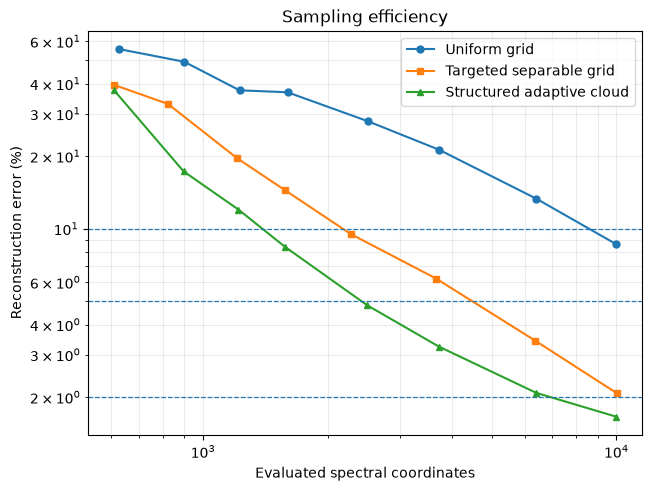

In [31]:
# ------------------------------------------------------------
# Sampling efficiency: reconstruction error vs evaluated points
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.4, 4.8),
    constrained_layout=True,
)

labels = {
    "uniform": "Uniform grid",
    "targeted": "Targeted separable grid",
    "structured": "Structured adaptive cloud",
}

markers = {
    "uniform": "o",
    "targeted": "s",
    "structured": "^",
}

for key in [
    "uniform",
    "targeted",
    "structured",
]:

    N_values = np.array([
        item["N"]
        for item in sampling_results[key]
    ])

    errors = 100.0 * np.array([
        item["global"]
        for item in sampling_results[key]
    ])

    ax.plot(
        N_values,
        errors,
        marker=markers[key],
        markersize=5,
        linewidth=1.5,
        label=labels[key],
    )


ax.axhline(
    10.0,
    linestyle="--",
    linewidth=0.9,
)

ax.axhline(
    5.0,
    linestyle="--",
    linewidth=0.9,
)

ax.axhline(
    2.0,
    linestyle="--",
    linewidth=0.9,
)

ax.set_xscale(
    "log"
)

ax.set_yscale(
    "log"
)

ax.set_xlabel(
    "Evaluated spectral coordinates"
)

ax.set_ylabel(
    "Reconstruction error (%)"
)

ax.set_title(
    "Sampling efficiency"
)

ax.legend()

ax.grid(
    alpha=0.25,
    which="both",
)

plt.show()

In [32]:
# ------------------------------------------------------------
# Estimate spectral-coordinate count required for fixed
# reconstruction-error thresholds
# ------------------------------------------------------------

def estimate_N_for_error(
    results,
    threshold_percent,
):
    N = np.array(
        [item["N"] for item in results],
        dtype=float,
    )

    error = 100.0 * np.array(
        [item["global"] for item in results],
        dtype=float,
    )

    # Sort by N
    order = np.argsort(N)
    N = N[order]
    error = error[order]

    # Find consecutive points that bracket the threshold
    for i in range(len(N) - 1):

        e1 = error[i]
        e2 = error[i + 1]

        if (
            (e1 >= threshold_percent >= e2)
            or
            (e2 >= threshold_percent >= e1)
        ):

            # log-log interpolation
            logN1 = np.log(N[i])
            logN2 = np.log(N[i + 1])

            loge1 = np.log(e1)
            loge2 = np.log(e2)

            log_threshold = np.log(
                threshold_percent
            )

            fraction = (
                (log_threshold - loge1)
                / (loge2 - loge1)
            )

            logN_threshold = (
                logN1
                + fraction
                * (logN2 - logN1)
            )

            return np.exp(
                logN_threshold
            )

    return None


thresholds = [
    10.0,
    5.0,
    2.0,
    1.0,
]

print("Estimated coordinate requirements")
print("---------------------------------")

for threshold in thresholds:

    print()
    print(
        f"{threshold:.0f}% reconstruction error"
    )

    for key, label in [
        ("uniform", "Uniform"),
        ("targeted", "Targeted separable"),
        ("structured", "Structured adaptive"),
    ]:

        N_required = estimate_N_for_error(
            sampling_results[key],
            threshold,
        )

        if N_required is None:

            print(
                f"{label:20s}: "
                "not reached in scanned range"
            )

        else:

            print(
                f"{label:20s}: "
                f"N ≈ {N_required:.0f}"
            )

Estimated coordinate requirements
---------------------------------

10% reconstruction error
Uniform             : N ≈ 8577
Targeted separable  : N ≈ 2176
Structured adaptive : N ≈ 1390

5% reconstruction error
Uniform             : not reached in scanned range
Targeted separable  : N ≈ 4476
Structured adaptive : N ≈ 2415

2% reconstruction error
Uniform             : not reached in scanned range
Targeted separable  : not reached in scanned range
Structured adaptive : N ≈ 6910

1% reconstruction error
Uniform             : not reached in scanned range
Targeted separable  : not reached in scanned range
Structured adaptive : not reached in scanned range


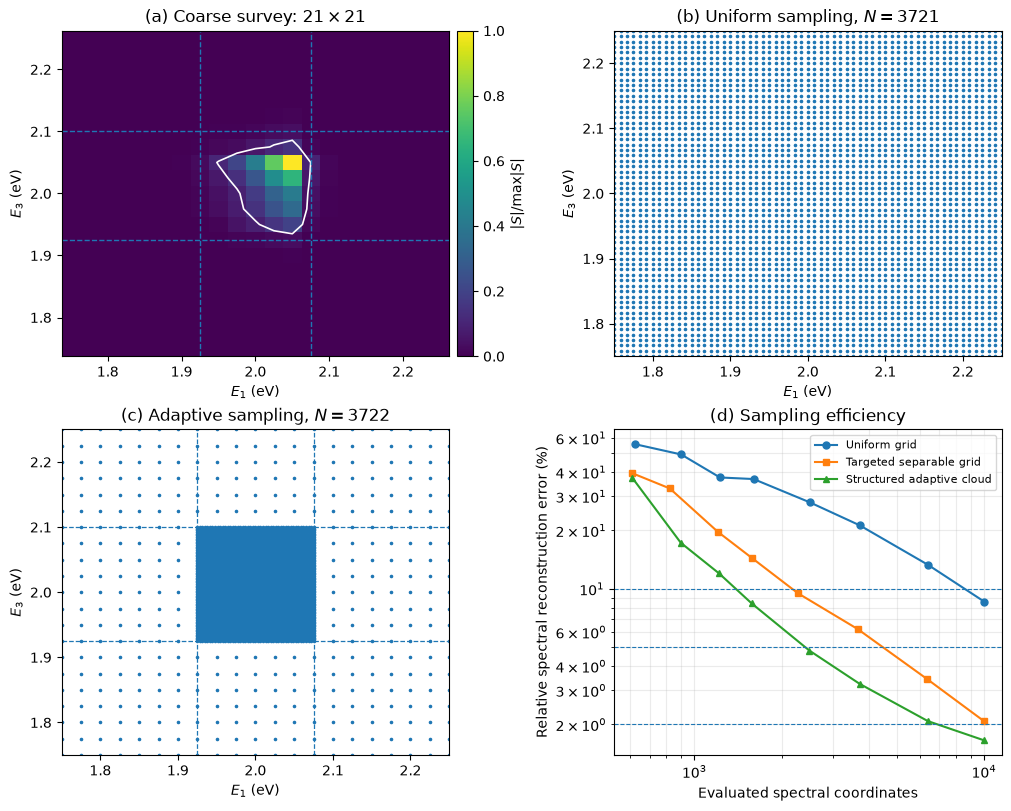

In [33]:
# ------------------------------------------------------------
# Draft publication Figure 3
# Targeted frequency-domain sampling
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.0, 8.0),
    constrained_layout=True,
)

# ============================================================
# (a) Coarse survey
# ============================================================

ax = axes[0, 0]

pcm = ax.pcolormesh(
    E1_coarse,
    E3_coarse,
    S_coarse_norm,
    shading="auto",
)

ax.contour(
    E1_coarse,
    E3_coarse,
    S_coarse_norm,
    levels=[activity_threshold],
    colors="white",
    linewidths=1.2,
)

# Automatically inferred target region
ax.axvline(
    E1_target_min,
    linestyle="--",
    linewidth=1.0,
)

ax.axvline(
    E1_target_max,
    linestyle="--",
    linewidth=1.0,
)

ax.axhline(
    E3_target_min,
    linestyle="--",
    linewidth=1.0,
)

ax.axhline(
    E3_target_max,
    linestyle="--",
    linewidth=1.0,
)

ax.set_title(
    r"(a) Coarse survey: $21\times21$"
)

ax.set_xlabel(
    r"$E_1$ (eV)"
)

ax.set_ylabel(
    r"$E_3$ (eV)"
)

cbar = fig.colorbar(
    pcm,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    r"$|S|/\max|S|$"
)


# ============================================================
# (b) Uniform sampling
# ============================================================

ax = axes[0, 1]

ax.scatter(
    E1u_mesh.ravel(),
    E3u_mesh.ravel(),
    s=2.5,
)

ax.set_title(
    rf"(b) Uniform sampling, $N={E1u_mesh.size}$"
)

ax.set_xlabel(
    r"$E_1$ (eV)"
)

ax.set_ylabel(
    r"$E_3$ (eV)"
)

ax.set_xlim(
    E_min,
    E_max,
)

ax.set_ylim(
    E_min,
    E_max,
)


# ============================================================
# (c) Structured adaptive sampling
# ============================================================

ax = axes[1, 0]

ax.scatter(
    E1_structured,
    E3_structured,
    s=2.5,
)

ax.axvline(
    E1_target_min,
    linestyle="--",
    linewidth=0.9,
)

ax.axvline(
    E1_target_max,
    linestyle="--",
    linewidth=0.9,
)

ax.axhline(
    E3_target_min,
    linestyle="--",
    linewidth=0.9,
)

ax.axhline(
    E3_target_max,
    linestyle="--",
    linewidth=0.9,
)

ax.set_title(
    rf"(c) Adaptive sampling, $N={N_structured}$"
)

ax.set_xlabel(
    r"$E_1$ (eV)"
)

ax.set_ylabel(
    r"$E_3$ (eV)"
)

ax.set_xlim(
    E_min,
    E_max,
)

ax.set_ylim(
    E_min,
    E_max,
)


# ============================================================
# (d) Sampling efficiency
# ============================================================

ax = axes[1, 1]

labels = {
    "uniform": "Uniform grid",
    "targeted": "Targeted separable grid",
    "structured": "Structured adaptive cloud",
}

markers = {
    "uniform": "o",
    "targeted": "s",
    "structured": "^",
}

for key in [
    "uniform",
    "targeted",
    "structured",
]:

    N_values = np.array([
        item["N"]
        for item in sampling_results[key]
    ])

    errors = 100.0 * np.array([
        item["global"]
        for item in sampling_results[key]
    ])

    ax.plot(
        N_values,
        errors,
        marker=markers[key],
        markersize=5,
        linewidth=1.5,
        label=labels[key],
    )

for level in [
    10.0,
    5.0,
    2.0,
]:

    ax.axhline(
        level,
        linestyle="--",
        linewidth=0.8,
    )

ax.set_xscale(
    "log"
)

ax.set_yscale(
    "log"
)

ax.set_xlabel(
    "Evaluated spectral coordinates"
)

ax.set_ylabel(
    "Relative spectral reconstruction error (%)"
)

ax.set_title(
    "(d) Sampling efficiency"
)

ax.legend(
    fontsize=8,
)

ax.grid(
    alpha=0.25,
    which="both",
)


plt.show()

In [34]:
# ------------------------------------------------------------
# Reload PULSUS after adding finite_pulse_points
# ------------------------------------------------------------

import importlib
import pulsus.spectra

importlib.reload(pulsus.spectra)
importlib.reload(pulsus)

print(
    "finite_pulse_points available:",
    hasattr(
        pulsus,
        "finite_pulse_points",
    ),
)

finite_pulse_points available: True


In [35]:
# ------------------------------------------------------------
# Verify optimized paired-coordinate evaluator
# ------------------------------------------------------------

S_points_optimized = pulsus.finite_pulse_points(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=E1_test / HBAR_EV_FS,
    omega3=E3_test / HBAR_EV_FS,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

relative_difference_optimized = (
    np.linalg.norm(
        S_points_optimized
        - S_grid_test
    )
    / np.linalg.norm(
        S_grid_test
    )
)

print(
    "Optimized points vs grid:"
)
print(
    f"{relative_difference_optimized:.3e}"
)

Optimized points vs grid:
1.142e-16


In [36]:
# ------------------------------------------------------------
# Benchmark optimized arbitrary-coordinate evaluator
# on the same structured adaptive cloud
# ------------------------------------------------------------

# Warm-up
_ = pulsus.finite_pulse_points(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=E1_structured / HBAR_EV_FS,
    omega3=E3_structured / HBAR_EV_FS,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

# Repeated timings
n_timing_runs = 25

point_times = []

for _ in range(n_timing_runs):

    t0 = time.perf_counter()

    S_structured_optimized = pulsus.finite_pulse_points(
        system=system,
        pulse1=pulse,
        pulse2=pulse,
        pulse3=pulse,
        omega1=E1_structured / HBAR_EV_FS,
        omega3=E3_structured / HBAR_EV_FS,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    point_times.append(
        time.perf_counter() - t0
    )

point_times = np.asarray(
    point_times
)

median_points_time = np.median(
    point_times
)

# Compare against the original slow notebook helper result
relative_difference_structured = (
    np.linalg.norm(
        S_structured_optimized
        - S_structured
    )
    / np.linalg.norm(
        S_structured
    )
)

old_helper_time = runtime_structured

speedup_vs_old = (
    old_helper_time
    / median_points_time
)

print("Optimized arbitrary-coordinate benchmark")
print("----------------------------------------")
print(
    f"points = {len(E1_structured)}"
)
print(
    f"unique omega1 = "
    f"{len(np.unique(E1_structured))}"
)
print(
    f"unique omega3 = "
    f"{len(np.unique(E3_structured))}"
)
print()
print(
    f"median optimized runtime = "
    f"{median_points_time:.6f} s"
)
print(
    f"old helper runtime       = "
    f"{old_helper_time:.6f} s"
)
print(
    f"speedup vs old helper    = "
    f"{speedup_vs_old:.1f}x"
)
print()
print(
    f"optimized vs old result  = "
    f"{relative_difference_structured:.3e}"
)

Optimized arbitrary-coordinate benchmark
----------------------------------------
points = 3722
unique omega1 = 65
unique omega3 = 85

median optimized runtime = 0.010979 s
old helper runtime       = 0.751529 s
speedup vs old helper    = 68.4x

optimized vs old result  = 3.628e-16


In [37]:
# ------------------------------------------------------------
# Fair runtime comparison at N ~ 3721
# ------------------------------------------------------------

def median_runtime(
    function,
    n_runs=25,
):
    # Warm-up
    function()

    times = []

    for _ in range(n_runs):

        t0 = time.perf_counter()

        function()

        times.append(
            time.perf_counter() - t0
        )

    return np.median(
        np.asarray(times)
    )


# ------------------------------------------------------------
# Uniform 61 x 61 Cartesian grid
# ------------------------------------------------------------

def run_uniform_61():

    return pulsus.finite_pulse_spectrum(
        system=system,
        pulse1=pulse,
        pulse2=pulse,
        pulse3=pulse,
        omega1=E1_uniform / HBAR_EV_FS,
        omega3=E3_uniform / HBAR_EV_FS,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )


# ------------------------------------------------------------
# Targeted separable 61 x 61 Cartesian grid
# ------------------------------------------------------------

def run_targeted_61():

    return pulsus.finite_pulse_spectrum(
        system=system,
        pulse1=pulse,
        pulse2=pulse,
        pulse3=pulse,
        omega1=E1_targeted / HBAR_EV_FS,
        omega3=E3_targeted / HBAR_EV_FS,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )


# ------------------------------------------------------------
# Structured arbitrary-coordinate cloud
# ------------------------------------------------------------

def run_structured_points():

    return pulsus.finite_pulse_points(
        system=system,
        pulse1=pulse,
        pulse2=pulse,
        pulse3=pulse,
        omega1=E1_structured / HBAR_EV_FS,
        omega3=E3_structured / HBAR_EV_FS,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )


t_uniform_61 = median_runtime(
    run_uniform_61
)

t_targeted_61 = median_runtime(
    run_targeted_61
)

t_structured_points = median_runtime(
    run_structured_points
)


print("Fair runtime comparison")
print("-----------------------")

print(
    f"Uniform grid       "
    f"N={E1u_mesh.size:4d}   "
    f"{t_uniform_61:.6f} s"
)

print(
    f"Targeted separable "
    f"N={E1t_mesh.size:4d}   "
    f"{t_targeted_61:.6f} s"
)

print(
    f"Structured cloud   "
    f"N={N_structured:4d}   "
    f"{t_structured_points:.6f} s"
)

Fair runtime comparison
-----------------------
Uniform grid       N=3721   0.009677 s
Targeted separable N=3721   0.009557 s
Structured cloud   N=3722   0.011252 s


In [38]:
# ------------------------------------------------------------
# Same-accuracy timing test near 10% reconstruction error
# ------------------------------------------------------------

n_timing_runs = 25

# ============================================================
# Uniform strategy: ~8577 predicted coordinates
# ============================================================

n_uniform_10 = 93

E1_uniform_10 = np.linspace(
    E_min,
    E_max,
    n_uniform_10,
)

E3_uniform_10 = np.linspace(
    E_min,
    E_max,
    n_uniform_10,
)


def run_uniform_10():

    return pulsus.finite_pulse_spectrum(
        system=system,
        pulse1=pulse,
        pulse2=pulse,
        pulse3=pulse,
        omega1=E1_uniform_10 / HBAR_EV_FS,
        omega3=E3_uniform_10 / HBAR_EV_FS,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )


# Warm-up
S_uniform_10 = run_uniform_10()

uniform_10_times = []

for _ in range(n_timing_runs):

    t0 = time.perf_counter()

    S_uniform_10 = run_uniform_10()

    uniform_10_times.append(
        time.perf_counter() - t0
    )

t_uniform_10 = np.median(
    uniform_10_times
)


# ============================================================
# Adaptive strategy: total budget ~1390
#
# Total cost includes:
#   1. 21 x 21 coarse survey
#   2. structured refinement
#
# The refinement rectangle is the one inferred from that survey.
# ============================================================

adaptive_budget_10 = 1390

(
    E1_patch_10,
    E3_patch_10,
    n1_patch_10,
    n3_patch_10,
) = build_structured_refinement(
    adaptive_budget_10
)


def run_adaptive_10():

    # Stage 1: coarse survey
    S_survey = pulsus.finite_pulse_spectrum(
        system=system,
        pulse1=pulse,
        pulse2=pulse,
        pulse3=pulse,
        omega1=E1_coarse / HBAR_EV_FS,
        omega3=E3_coarse / HBAR_EV_FS,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    # Stage 2: direct refinement at requested paired coordinates
    S_patch = pulsus.finite_pulse_points(
        system=system,
        pulse1=pulse,
        pulse2=pulse,
        pulse3=pulse,
        omega1=E1_patch_10 / HBAR_EV_FS,
        omega3=E3_patch_10 / HBAR_EV_FS,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )

    return S_survey, S_patch


# Warm-up
S_survey_10, S_patch_10 = run_adaptive_10()

adaptive_10_times = []

for _ in range(n_timing_runs):

    t0 = time.perf_counter()

    S_survey_10, S_patch_10 = run_adaptive_10()

    adaptive_10_times.append(
        time.perf_counter() - t0
    )

t_adaptive_10 = np.median(
    adaptive_10_times
)


# ============================================================
# Merge adaptive samples for accuracy evaluation
# ============================================================

E1c_mesh, E3c_mesh = np.meshgrid(
    E1_coarse,
    E3_coarse,
)

(
    E1_adaptive_10,
    E3_adaptive_10,
    S_adaptive_10,
) = merge_unique_samples(
    E1c_mesh.ravel(),
    E3c_mesh.ravel(),
    S_survey_10.ravel(),
    E1_patch_10,
    E3_patch_10,
    S_patch_10,
)

N_adaptive_10 = len(
    S_adaptive_10
)

N_uniform_10 = S_uniform_10.size


# ============================================================
# Reconstruct both onto the dense reference grid
# ============================================================

E1u10_mesh, E3u10_mesh = np.meshgrid(
    E1_uniform_10,
    E3_uniform_10,
)

S_uniform_10_interp = reconstruct_scattered(
    E1u10_mesh.ravel(),
    E3u10_mesh.ravel(),
    S_uniform_10.ravel(),
    E1_reference,
    E3_reference,
)

S_adaptive_10_interp = reconstruct_scattered(
    E1_adaptive_10,
    E3_adaptive_10,
    S_adaptive_10,
    E1_reference,
    E3_reference,
)

err_uniform_10 = relative_frobenius_error(
    S_uniform_10_interp,
    S_reference,
)

err_adaptive_10 = relative_frobenius_error(
    S_adaptive_10_interp,
    S_reference,
)


# ============================================================
# Summary
# ============================================================

print("Same-accuracy timing test")
print("-------------------------")

print(
    f"Uniform:"
    f"   N = {N_uniform_10}"
    f"   error = {100*err_uniform_10:.3f}%"
    f"   time = {1000*t_uniform_10:.3f} ms"
)

print(
    f"Adaptive:"
    f"  N = {N_adaptive_10}"
    f"   error = {100*err_adaptive_10:.3f}%"
    f"   time = {1000*t_adaptive_10:.3f} ms"
)

print()

print(
    "Coordinate reduction = "
    f"{N_uniform_10 / N_adaptive_10:.2f}x"
)

print(
    "Runtime ratio "
    "(uniform/adaptive) = "
    f"{t_uniform_10 / t_adaptive_10:.2f}x"
)

print()

print(
    f"Adaptive patch = "
    f"{n1_patch_10} x {n3_patch_10}"
)

Same-accuracy timing test
-------------------------
Uniform:   N = 8649   error = 10.039%   time = 13.869 ms
Adaptive:  N = 1392   error = 9.099%   time = 7.786 ms

Coordinate reduction = 6.21x
Runtime ratio (uniform/adaptive) = 1.78x

Adaptive patch = 29 x 33


In [48]:
# ============================================================
# Full timing scan
#
# Matches the sampling budgets already used in sampling_results.
#
# Adaptive timings include:
#   1. the 21 x 21 coarse survey
#   2. only NEW refinement coordinates
#
# Reconstruction/interpolation time is NOT included because it
# is a benchmark diagnostic, not part of the PULSUS calculation.
# ============================================================

n_timing_runs = 25

budgets = [
    int(result["requested"])
    for result in sampling_results["uniform"]
]

# Exact target rectangle identified earlier from the 21 x 21 survey
E1_target_min_timing = 1.925
E1_target_max_timing = 2.075

E3_target_min_timing = 1.925
E3_target_max_timing = 2.100


# ------------------------------------------------------------
# Coarse survey coordinates
# ------------------------------------------------------------

E1c_mesh, E3c_mesh = np.meshgrid(
    E1_coarse,
    E3_coarse,
)

E1_coarse_points = E1c_mesh.ravel()
E3_coarse_points = E3c_mesh.ravel()

coarse_N = E1_coarse_points.size

coarse_keys = {
    (
        round(float(e1), 12),
        round(float(e3), 12),
    )
    for e1, e3 in zip(
        E1_coarse_points,
        E3_coarse_points,
    )
}


# ------------------------------------------------------------
# Remove refinement points already evaluated in coarse survey
# ------------------------------------------------------------

def remove_coarse_duplicates(
    E1_points,
    E3_points,
):

    E1_points = np.asarray(
        E1_points,
        dtype=float,
    )

    E3_points = np.asarray(
        E3_points,
        dtype=float,
    )

    keep = np.array(
        [
            (
                round(float(e1), 12),
                round(float(e3), 12),
            )
            not in coarse_keys

            for e1, e3 in zip(
                E1_points,
                E3_points,
            )
        ],
        dtype=bool,
    )

    return (
        E1_points[keep],
        E3_points[keep],
    )


# ------------------------------------------------------------
# Median timing helper
# ------------------------------------------------------------

def benchmark_median(
    function,
    n_runs=25,
):

    # Warm-up
    function()

    times = np.empty(
        n_runs,
        dtype=float,
    )

    for i in range(n_runs):

        t0 = time.perf_counter()

        function()

        times[i] = (
            time.perf_counter()
            - t0
        )

    return np.median(times)


# ------------------------------------------------------------
# Common survey calculation
# ------------------------------------------------------------

def run_coarse_survey():

    return pulsus.finite_pulse_spectrum(
        system=system,
        pulse1=pulse,
        pulse2=pulse,
        pulse3=pulse,
        omega1=E1_coarse / HBAR_EV_FS,
        omega3=E3_coarse / HBAR_EV_FS,
        T=T_fs,
        eta=eta,
        pathway="NR",
    )


# ------------------------------------------------------------
# Result container
# ------------------------------------------------------------

timing_results = {
    "uniform": [],
    "targeted": [],
    "structured": [],
}


# ============================================================
# Scan
# ============================================================

for index, budget in enumerate(budgets):

    print(
        f"Budget {budget} ..."
    )

    # ========================================================
    # 1. UNIFORM GRID
    # ========================================================

    stored_uniform = (
        sampling_results["uniform"][index]
    )

    N_uniform = int(
        stored_uniform["N"]
    )

    n_uniform = int(
        round(
            np.sqrt(N_uniform)
        )
    )

    E1_uniform_scan = np.linspace(
        E_min,
        E_max,
        n_uniform,
    )

    E3_uniform_scan = np.linspace(
        E_min,
        E_max,
        n_uniform,
    )

    def run_uniform():

        return pulsus.finite_pulse_spectrum(
            system=system,
            pulse1=pulse,
            pulse2=pulse,
            pulse3=pulse,
            omega1=(
                E1_uniform_scan
                / HBAR_EV_FS
            ),
            omega3=(
                E3_uniform_scan
                / HBAR_EV_FS
            ),
            T=T_fs,
            eta=eta,
            pathway="NR",
        )

    t_uniform = benchmark_median(
        run_uniform,
        n_runs=n_timing_runs,
    )

    timing_results["uniform"].append(
        {
            "requested": budget,
            "N": N_uniform,
            "global": float(
                stored_uniform["global"]
            ),
            "time_s": t_uniform,
            "time_ms": 1000 * t_uniform,
            "unique_omega1": n_uniform,
            "unique_omega3": n_uniform,
        }
    )


    # ========================================================
    # 2. TARGETED SEPARABLE GRID
    #
    # Remaining budget after coarse survey determines
    # the approximate refinement-axis size.
    # ========================================================

    stored_targeted = (
        sampling_results["targeted"][index]
    )

    remaining_budget = (
        budget - coarse_N
    )

    n_targeted_axis = int(
        round(
            np.sqrt(
                remaining_budget
            )
        )
    )

    E1_targeted_scan = targeted_axis(
        E_min,
        E_max,
        E1_target_min_timing,
        E1_target_max_timing,
        n_targeted_axis,
        target_fraction=0.70,
    )

    E3_targeted_scan = targeted_axis(
        E_min,
        E_max,
        E3_target_min_timing,
        E3_target_max_timing,
        n_targeted_axis,
        target_fraction=0.70,
    )

    E1t_mesh, E3t_mesh = np.meshgrid(
        E1_targeted_scan,
        E3_targeted_scan,
    )

    E1_targeted_new, E3_targeted_new = (
        remove_coarse_duplicates(
            E1t_mesh.ravel(),
            E3t_mesh.ravel(),
        )
    )

    N_targeted = (
        coarse_N
        + len(E1_targeted_new)
    )

    # Exact consistency check with stored scan
    assert (
        N_targeted
        == int(
            stored_targeted["N"]
        )
    ), (
        f"Targeted N mismatch at "
        f"budget {budget}: "
        f"{N_targeted} != "
        f"{stored_targeted['N']}"
    )

    def run_targeted():

        # Stage 1
        run_coarse_survey()

        # Stage 2: only coordinates not already
        # evaluated by the survey
        return pulsus.finite_pulse_points(
            system=system,
            pulse1=pulse,
            pulse2=pulse,
            pulse3=pulse,
            omega1=(
                E1_targeted_new
                / HBAR_EV_FS
            ),
            omega3=(
                E3_targeted_new
                / HBAR_EV_FS
            ),
            T=T_fs,
            eta=eta,
            pathway="NR",
        )

    t_targeted = benchmark_median(
        run_targeted,
        n_runs=n_timing_runs,
    )

    E1_targeted_all = np.concatenate(
        [
            E1_coarse_points,
            E1_targeted_new,
        ]
    )

    E3_targeted_all = np.concatenate(
        [
            E3_coarse_points,
            E3_targeted_new,
        ]
    )

    timing_results["targeted"].append(
        {
            "requested": budget,
            "N": N_targeted,
            "global": float(
                stored_targeted["global"]
            ),
            "time_s": t_targeted,
            "time_ms": 1000 * t_targeted,
            "unique_omega1": len(
                np.unique(
                    E1_targeted_all
                )
            ),
            "unique_omega3": len(
                np.unique(
                    E3_targeted_all
                )
            ),
        }
    )


    # ========================================================
    # 3. STRUCTURED ADAPTIVE CLOUD
    # ========================================================

    stored_structured = (
        sampling_results["structured"][index]
    )

    (
        E1_patch_scan,
        E3_patch_scan,
        n1_patch_scan,
        n3_patch_scan,
    ) = build_structured_refinement(
        budget
    )

    # Make sure this is exactly the same patch
    # geometry used in the error scan
    assert (
        (
            n1_patch_scan,
            n3_patch_scan,
        )
        == tuple(
            stored_structured[
                "patch_shape"
            ]
        )
    )

    (
        E1_structured_new,
        E3_structured_new,
    ) = remove_coarse_duplicates(
        E1_patch_scan,
        E3_patch_scan,
    )

    N_structured_scan = (
        coarse_N
        + len(E1_structured_new)
    )

    assert (
        N_structured_scan
        == int(
            stored_structured["N"]
        )
    ), (
        f"Structured N mismatch at "
        f"budget {budget}: "
        f"{N_structured_scan} != "
        f"{stored_structured['N']}"
    )

    def run_structured():

        # Stage 1
        run_coarse_survey()

        # Stage 2
        return pulsus.finite_pulse_points(
            system=system,
            pulse1=pulse,
            pulse2=pulse,
            pulse3=pulse,
            omega1=(
                E1_structured_new
                / HBAR_EV_FS
            ),
            omega3=(
                E3_structured_new
                / HBAR_EV_FS
            ),
            T=T_fs,
            eta=eta,
            pathway="NR",
        )

    t_structured = benchmark_median(
        run_structured,
        n_runs=n_timing_runs,
    )

    E1_structured_all = np.concatenate(
        [
            E1_coarse_points,
            E1_structured_new,
        ]
    )

    E3_structured_all = np.concatenate(
        [
            E3_coarse_points,
            E3_structured_new,
        ]
    )

    timing_results["structured"].append(
        {
            "requested": budget,
            "N": N_structured_scan,
            "global": float(
                stored_structured["global"]
            ),
            "time_s": t_structured,
            "time_ms": 1000 * t_structured,
            "unique_omega1": len(
                np.unique(
                    E1_structured_all
                )
            ),
            "unique_omega3": len(
                np.unique(
                    E3_structured_all
                )
            ),
            "patch_shape": (
                n1_patch_scan,
                n3_patch_scan,
            ),
        }
    )


# ============================================================
# Print compact table
# ============================================================

print()
print(
    "FULL TIMING SCAN"
)
print(
    "----------------"
)

for i, budget in enumerate(budgets):

    u = timing_results[
        "uniform"
    ][i]

    t = timing_results[
        "targeted"
    ][i]

    s = timing_results[
        "structured"
    ][i]

    print()
    print(
        f"Requested budget: {budget}"
    )

    print(
        f"  Uniform     "
        f"N={u['N']:5d}   "
        f"err={100*u['global']:7.3f}%   "
        f"time={u['time_ms']:7.3f} ms   "
        f"unique=({u['unique_omega1']},"
        f"{u['unique_omega3']})"
    )

    print(
        f"  Targeted    "
        f"N={t['N']:5d}   "
        f"err={100*t['global']:7.3f}%   "
        f"time={t['time_ms']:7.3f} ms   "
        f"unique=({t['unique_omega1']},"
        f"{t['unique_omega3']})"
    )

    print(
        f"  Structured  "
        f"N={s['N']:5d}   "
        f"err={100*s['global']:7.3f}%   "
        f"time={s['time_ms']:7.3f} ms   "
        f"unique=({s['unique_omega1']},"
        f"{s['unique_omega3']})"
    )

Budget 625 ...
Budget 900 ...
Budget 1225 ...
Budget 1600 ...
Budget 2500 ...
Budget 3721 ...
Budget 6400 ...
Budget 10000 ...

FULL TIMING SCAN
----------------

Requested budget: 625
  Uniform     N=  625   err= 55.686%   time=  3.939 ms   unique=(25,25)
  Targeted    N=  607   err= 39.601%   time=  5.301 ms   unique=(30,30)
  Structured  N=  609   err= 37.511%   time=  5.368 ms   unique=(30,33)

Requested budget: 900
  Uniform     N=  900   err= 49.320%   time=  4.627 ms   unique=(30,30)
  Targeted    N=  822   err= 32.948%   time=  6.356 ms   unique=(37,31)
  Structured  N=  897   err= 17.285%   time=  6.386 ms   unique=(39,42)

Requested budget: 1225
  Uniform     N= 1225   err= 37.531%   time=  5.470 ms   unique=(35,35)
  Targeted    N= 1205   err= 19.676%   time=  7.352 ms   unique=(45,44)
  Structured  N= 1217   err= 12.005%   time=  7.328 ms   unique=(45,49)

Requested budget: 1600
  Uniform     N= 1600   err= 36.839%   time=  6.269 ms   unique=(40,40)
  Targeted    N= 1581   

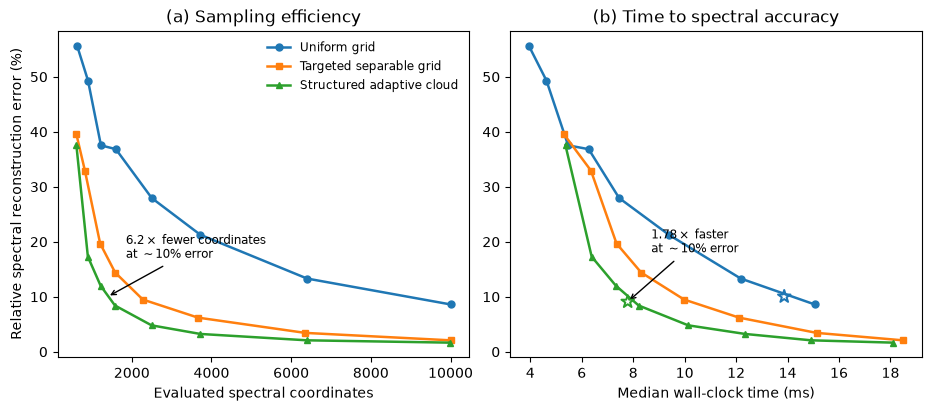

In [50]:
# ============================================================
# Figure 4 — Sampling efficiency and time-to-accuracy
# ============================================================

strategies = [
    ("uniform", "Uniform grid", "o"),
    ("targeted", "Targeted separable grid", "s"),
    ("structured", "Structured adaptive cloud", "^"),
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.2, 4.0),
    constrained_layout=True,
)

axN, axT = axes


# ------------------------------------------------------------
# (a) Reconstruction error vs evaluated coordinates
# ------------------------------------------------------------

for key, label, marker in strategies:

    N_values = np.array(
        [
            result["N"]
            for result in sampling_results[key]
        ],
        dtype=float,
    )

    errors = 100 * np.array(
        [
            result["global"]
            for result in sampling_results[key]
        ],
        dtype=float,
    )

    axN.plot(
        N_values,
        errors,
        marker=marker,
        linewidth=1.8,
        markersize=5,
        label=label,
    )


# ------------------------------------------------------------
# (b) Reconstruction error vs wall-clock time
# ------------------------------------------------------------

for key, label, marker in strategies:

    times_ms = np.array(
        [
            result["time_ms"]
            for result in timing_results[key]
        ],
        dtype=float,
    )

    errors = 100 * np.array(
        [
            result["global"]
            for result in timing_results[key]
        ],
        dtype=float,
    )

    axT.plot(
        times_ms,
        errors,
        marker=marker,
        linewidth=1.8,
        markersize=5,
        label=label,
    )


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

axN.set_xlabel(
    "Evaluated spectral coordinates"
)

axT.set_xlabel(
    "Median wall-clock time (ms)"
)

axN.set_ylabel(
    "Relative spectral reconstruction error (%)"
)

axN.set_title(
    "(a) Sampling efficiency"
)

axT.set_title(
    "(b) Time to spectral accuracy"
)

axN.legend(
    frameon=False,
    fontsize=8.5,
)


# ------------------------------------------------------------
# Direct matched-accuracy benchmark points
# ------------------------------------------------------------

axT.scatter(
    [1000 * t_uniform_10],
    [100 * err_uniform_10],
    marker="*",
    s=90,
    facecolors="none",
    edgecolors="C0",
    linewidths=1.4,
    zorder=5,
)

axT.scatter(
    [1000 * t_adaptive_10],
    [100 * err_adaptive_10],
    marker="*",
    s=90,
    facecolors="none",
    edgecolors="C2",
    linewidths=1.4,
    zorder=5,
)


# ------------------------------------------------------------
# Compact annotations
# ------------------------------------------------------------

axN.annotate(
    r"$6.2\times$ fewer coordinates"
    "\n"
    r"at $\sim10\%$ error",
    xy=(1390, 10),
    xytext=(1850, 17),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.0,
    ),
    fontsize=8.3,
)

axT.annotate(
    r"$1.78\times$ faster"
    "\n"
    r"at $\sim10\%$ error",
    xy=(
        1000 * t_adaptive_10,
        100 * err_adaptive_10,
    ),
    xytext=(8.7, 18),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.0,
    ),
    fontsize=8.3,
)

plt.show()

Uniform:   N=3721, error=21.265%
Adaptive:  N=3721, error=3.236%


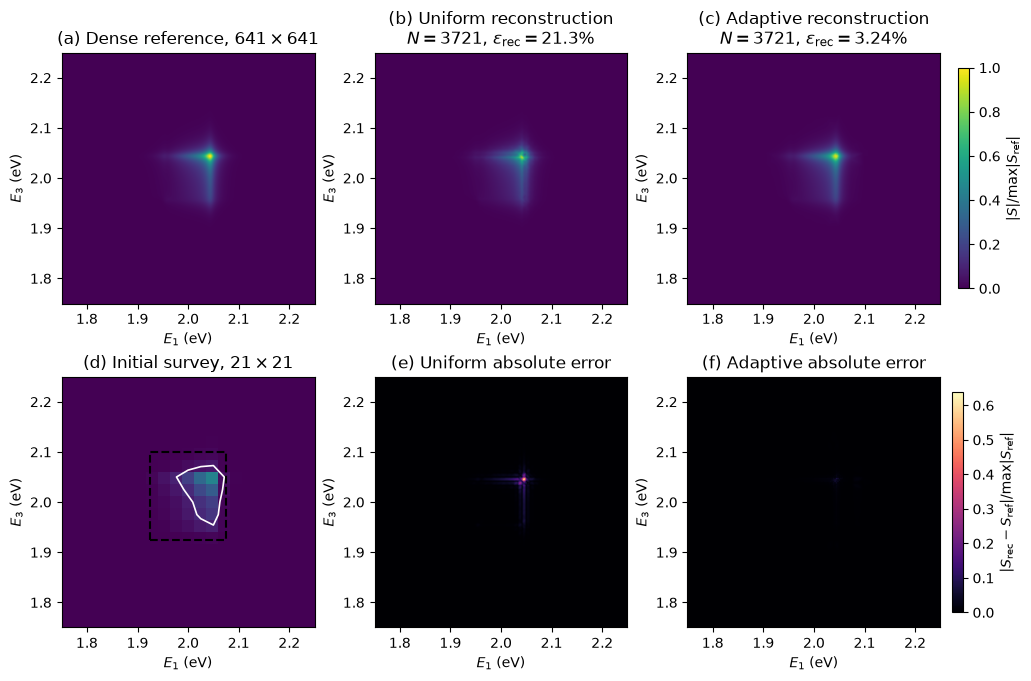

In [51]:
# ============================================================
# Figure 3 — Direct spectral reconstruction
# ============================================================

from matplotlib.patches import Rectangle

# ------------------------------------------------------------
# Equal-budget benchmark
# ------------------------------------------------------------

budget_fig3 = 3721

# ============================================================
# Uniform 61 x 61 sampling
# ============================================================

n_uniform_fig3 = 61

E1_uniform_fig3 = np.linspace(
    E_min,
    E_max,
    n_uniform_fig3,
)

E3_uniform_fig3 = np.linspace(
    E_min,
    E_max,
    n_uniform_fig3,
)

S_uniform_fig3 = pulsus.finite_pulse_spectrum(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=E1_uniform_fig3 / HBAR_EV_FS,
    omega3=E3_uniform_fig3 / HBAR_EV_FS,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

E1u_fig3_mesh, E3u_fig3_mesh = np.meshgrid(
    E1_uniform_fig3,
    E3_uniform_fig3,
)

S_uniform_fig3_rec = reconstruct_scattered(
    E1u_fig3_mesh.ravel(),
    E3u_fig3_mesh.ravel(),
    S_uniform_fig3.ravel(),
    E1_reference,
    E3_reference,
)


# ============================================================
# Structured adaptive sampling
# ============================================================

(
    E1_patch_fig3,
    E3_patch_fig3,
    n1_patch_fig3,
    n3_patch_fig3,
) = build_structured_refinement(
    budget_fig3
)

# Remove coordinates already evaluated in coarse survey
(
    E1_patch_fig3_new,
    E3_patch_fig3_new,
) = remove_coarse_duplicates(
    E1_patch_fig3,
    E3_patch_fig3,
)

S_patch_fig3 = pulsus.finite_pulse_points(
    system=system,
    pulse1=pulse,
    pulse2=pulse,
    pulse3=pulse,
    omega1=E1_patch_fig3_new / HBAR_EV_FS,
    omega3=E3_patch_fig3_new / HBAR_EV_FS,
    T=T_fs,
    eta=eta,
    pathway="NR",
)

# Merge survey + refinement
(
    E1_adaptive_fig3,
    E3_adaptive_fig3,
    S_adaptive_fig3,
) = merge_unique_samples(
    E1_coarse_points,
    E3_coarse_points,
    S_coarse.ravel(),
    E1_patch_fig3_new,
    E3_patch_fig3_new,
    S_patch_fig3,
)

N_adaptive_fig3 = len(
    S_adaptive_fig3
)

S_adaptive_fig3_rec = reconstruct_scattered(
    E1_adaptive_fig3,
    E3_adaptive_fig3,
    S_adaptive_fig3,
    E1_reference,
    E3_reference,
)


# ============================================================
# Reconstruction errors
# ============================================================

err_uniform_fig3 = relative_frobenius_error(
    S_uniform_fig3_rec,
    S_reference,
)

err_adaptive_fig3 = relative_frobenius_error(
    S_adaptive_fig3_rec,
    S_reference,
)

print(
    f"Uniform:   N={S_uniform_fig3.size}, "
    f"error={100*err_uniform_fig3:.3f}%"
)

print(
    f"Adaptive:  N={N_adaptive_fig3}, "
    f"error={100*err_adaptive_fig3:.3f}%"
)


# ============================================================
# Normalized magnitudes
# ============================================================

reference_scale = np.max(
    np.abs(S_reference)
)

A_reference = (
    np.abs(S_reference)
    / reference_scale
)

A_uniform = (
    np.abs(S_uniform_fig3_rec)
    / reference_scale
)

A_adaptive = (
    np.abs(S_adaptive_fig3_rec)
    / reference_scale
)

A_coarse = (
    np.abs(S_coarse)
    / reference_scale
)


# ------------------------------------------------------------
# Pointwise reconstruction-error maps
# ------------------------------------------------------------

D_uniform = (
    np.abs(
        S_uniform_fig3_rec
        - S_reference
    )
    / reference_scale
)

D_adaptive = (
    np.abs(
        S_adaptive_fig3_rec
        - S_reference
    )
    / reference_scale
)

error_vmax = max(
    np.max(D_uniform),
    np.max(D_adaptive),
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(10.2, 6.7),
    constrained_layout=True,
)

extent = [
    E_min,
    E_max,
    E_min,
    E_max,
]


# ------------------------------------------------------------
# (a) Dense reference
# ------------------------------------------------------------

im_amp = axes[0, 0].imshow(
    A_reference,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=1,
)

axes[0, 0].set_title(
    r"(a) Dense reference, $641\times641$"
)


# ------------------------------------------------------------
# (b) Uniform reconstruction
# ------------------------------------------------------------

axes[0, 1].imshow(
    A_uniform,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=1,
)

axes[0, 1].set_title(
    "(b) Uniform reconstruction\n"
    + rf"$N={S_uniform_fig3.size}$, "
    + rf"$\epsilon_{{\rm rec}}={100*err_uniform_fig3:.1f}\%$"
)


# ------------------------------------------------------------
# (c) Adaptive reconstruction
# ------------------------------------------------------------

axes[0, 2].imshow(
    A_adaptive,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=1,
)

axes[0, 2].set_title(
    "(c) Adaptive reconstruction\n"
    + rf"$N={N_adaptive_fig3}$, "
    + rf"$\epsilon_{{\rm rec}}={100*err_adaptive_fig3:.2f}\%$"
)


# ------------------------------------------------------------
# (d) Coarse survey
# ------------------------------------------------------------

axes[1, 0].imshow(
    A_coarse,
    origin="lower",
    extent=extent,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

axes[1, 0].contour(
    E1_coarse,
    E3_coarse,
    A_coarse,
    levels=[0.10],
    colors="white",
    linewidths=1.2,
)

target_rectangle = Rectangle(
    (
        E1_target_min_timing,
        E3_target_min_timing,
    ),
    (
        E1_target_max_timing
        - E1_target_min_timing
    ),
    (
        E3_target_max_timing
        - E3_target_min_timing
    ),
    fill=False,
    linestyle="--",
    linewidth=1.5,
)

axes[1, 0].add_patch(
    target_rectangle
)

axes[1, 0].set_title(
    r"(d) Initial survey, $21\times21$"
)


# ------------------------------------------------------------
# (e) Uniform reconstruction error
# ------------------------------------------------------------

im_err = axes[1, 1].imshow(
    D_uniform,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=error_vmax,
    cmap="magma",
)

axes[1, 1].set_title(
    "(e) Uniform absolute error"
)


# ------------------------------------------------------------
# (f) Adaptive reconstruction error
# ------------------------------------------------------------

axes[1, 2].imshow(
    D_adaptive,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=error_vmax,
    cmap="magma",
)

axes[1, 2].set_title(
    "(f) Adaptive absolute error"
)


# ============================================================
# Axis formatting
# ============================================================

for row in range(2):

    for col in range(3):

        axes[row, col].set_xlabel(
            r"$E_1$ (eV)"
        )

        axes[row, col].set_ylabel(
            r"$E_3$ (eV)"
        )

        axes[row, col].set_xlim(
            E_min,
            E_max,
        )

        axes[row, col].set_ylim(
            E_min,
            E_max,
        )


# ------------------------------------------------------------
# Shared colorbars
# ------------------------------------------------------------

cbar_amp = fig.colorbar(
    im_amp,
    ax=axes[0, :],
    shrink=0.88,
    pad=0.02,
)

cbar_amp.set_label(
    r"$|S|/\max|S_{\rm ref}|$"
)

cbar_err = fig.colorbar(
    im_err,
    ax=axes[1, 1:],
    shrink=0.88,
    pad=0.02,
)

cbar_err.set_label(
    r"$|S_{\rm rec}-S_{\rm ref}|/\max|S_{\rm ref}|$"
)

plt.show()

Sampling patterns:
Uniform:    N=3721
Targeted:   N=3660
Structured: N=3721


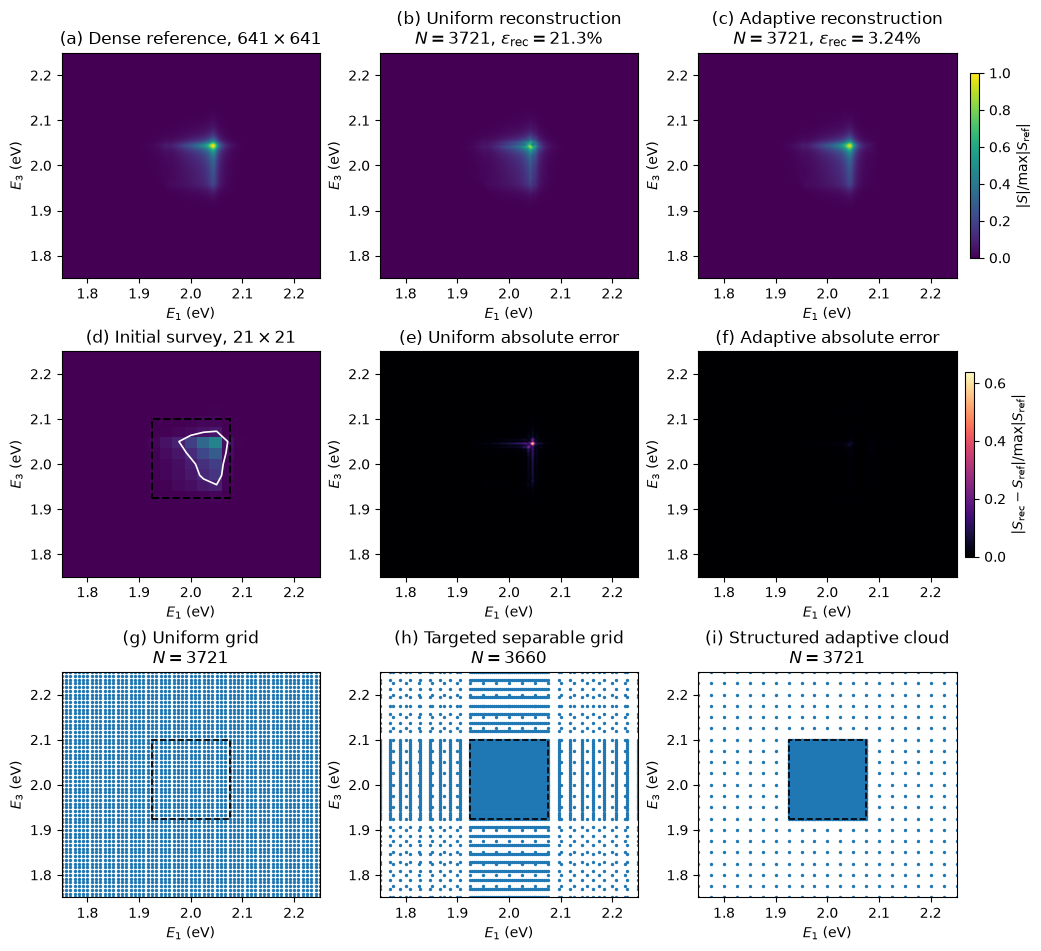

In [52]:
# ============================================================
# Figure 3 — Reconstruction + sampling geometries
# ============================================================

from matplotlib.patches import Rectangle

budget_fig3 = 3721


# ============================================================
# Build the three sampling patterns at the ~3721 budget
# ============================================================

# ------------------------------------------------------------
# Uniform
# ------------------------------------------------------------

E1_uniform_pattern = E1_uniform_fig3
E3_uniform_pattern = E3_uniform_fig3

E1_uniform_mesh, E3_uniform_mesh = np.meshgrid(
    E1_uniform_pattern,
    E3_uniform_pattern,
)

E1_uniform_points = E1_uniform_mesh.ravel()
E3_uniform_points = E3_uniform_mesh.ravel()

N_uniform_pattern = len(
    E1_uniform_points
)


# ------------------------------------------------------------
# Targeted separable
#
# Includes the original 21 x 21 survey in the total budget.
# ------------------------------------------------------------

remaining_budget = (
    budget_fig3
    - coarse_N
)

n_targeted_axis_fig3 = int(
    round(
        np.sqrt(
            remaining_budget
        )
    )
)

E1_targeted_pattern = targeted_axis(
    E_min,
    E_max,
    E1_target_min_timing,
    E1_target_max_timing,
    n_targeted_axis_fig3,
    target_fraction=0.70,
)

E3_targeted_pattern = targeted_axis(
    E_min,
    E_max,
    E3_target_min_timing,
    E3_target_max_timing,
    n_targeted_axis_fig3,
    target_fraction=0.70,
)

E1t_mesh, E3t_mesh = np.meshgrid(
    E1_targeted_pattern,
    E3_targeted_pattern,
)

(
    E1_targeted_new,
    E3_targeted_new,
) = remove_coarse_duplicates(
    E1t_mesh.ravel(),
    E3t_mesh.ravel(),
)

E1_targeted_points = np.concatenate(
    [
        E1_coarse_points,
        E1_targeted_new,
    ]
)

E3_targeted_points = np.concatenate(
    [
        E3_coarse_points,
        E3_targeted_new,
    ]
)

N_targeted_pattern = len(
    E1_targeted_points
)


# ------------------------------------------------------------
# Structured adaptive
# ------------------------------------------------------------

(
    E1_structured_patch,
    E3_structured_patch,
    n1_structured_fig3,
    n3_structured_fig3,
) = build_structured_refinement(
    budget_fig3
)

(
    E1_structured_new,
    E3_structured_new,
) = remove_coarse_duplicates(
    E1_structured_patch,
    E3_structured_patch,
)

E1_structured_points = np.concatenate(
    [
        E1_coarse_points,
        E1_structured_new,
    ]
)

E3_structured_points = np.concatenate(
    [
        E3_coarse_points,
        E3_structured_new,
    ]
)

N_structured_pattern = len(
    E1_structured_points
)


print(
    "Sampling patterns:"
)

print(
    f"Uniform:    N={N_uniform_pattern}"
)

print(
    f"Targeted:   N={N_targeted_pattern}"
)

print(
    f"Structured: N={N_structured_pattern}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(10.3, 9.4),
    constrained_layout=True,
)

extent = [
    E_min,
    E_max,
    E_min,
    E_max,
]


# ============================================================
# ROW 1 — Reference and reconstructions
# ============================================================

# ------------------------------------------------------------
# (a) Dense reference
# ------------------------------------------------------------

im_amp = axes[0, 0].imshow(
    A_reference,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=1,
)

axes[0, 0].set_title(
    r"(a) Dense reference, $641\times641$"
)


# ------------------------------------------------------------
# (b) Uniform reconstruction
# ------------------------------------------------------------

axes[0, 1].imshow(
    A_uniform,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=1,
)

axes[0, 1].set_title(
    "(b) Uniform reconstruction\n"
    + rf"$N={S_uniform_fig3.size}$, "
    + rf"$\epsilon_{{\rm rec}}={100*err_uniform_fig3:.1f}\%$"
)


# ------------------------------------------------------------
# (c) Adaptive reconstruction
# ------------------------------------------------------------

axes[0, 2].imshow(
    A_adaptive,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=1,
)

axes[0, 2].set_title(
    "(c) Adaptive reconstruction\n"
    + rf"$N={N_adaptive_fig3}$, "
    + rf"$\epsilon_{{\rm rec}}={100*err_adaptive_fig3:.2f}\%$"
)


# ============================================================
# ROW 2 — Survey and reconstruction errors
# ============================================================

# ------------------------------------------------------------
# (d) Coarse survey
# ------------------------------------------------------------

axes[1, 0].imshow(
    A_coarse,
    origin="lower",
    extent=extent,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

axes[1, 0].contour(
    E1_coarse,
    E3_coarse,
    A_coarse,
    levels=[0.10],
    colors="white",
    linewidths=1.2,
)

axes[1, 0].add_patch(
    Rectangle(
        (
            E1_target_min_timing,
            E3_target_min_timing,
        ),
        (
            E1_target_max_timing
            - E1_target_min_timing
        ),
        (
            E3_target_max_timing
            - E3_target_min_timing
        ),
        fill=False,
        linestyle="--",
        linewidth=1.4,
    )
)

axes[1, 0].set_title(
    r"(d) Initial survey, $21\times21$"
)


# ------------------------------------------------------------
# (e) Uniform error
# ------------------------------------------------------------

im_err = axes[1, 1].imshow(
    D_uniform,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=error_vmax,
    cmap="magma",
)

axes[1, 1].set_title(
    "(e) Uniform absolute error"
)


# ------------------------------------------------------------
# (f) Adaptive error
# ------------------------------------------------------------

axes[1, 2].imshow(
    D_adaptive,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=error_vmax,
    cmap="magma",
)

axes[1, 2].set_title(
    "(f) Adaptive absolute error"
)


# ============================================================
# ROW 3 — Sampling geometries
# ============================================================

sampling_panels = [
    (
        axes[2, 0],
        E1_uniform_points,
        E3_uniform_points,
        N_uniform_pattern,
        "(g) Uniform grid",
    ),
    (
        axes[2, 1],
        E1_targeted_points,
        E3_targeted_points,
        N_targeted_pattern,
        "(h) Targeted separable grid",
    ),
    (
        axes[2, 2],
        E1_structured_points,
        E3_structured_points,
        N_structured_pattern,
        "(i) Structured adaptive cloud",
    ),
]


for (
    ax,
    E1_points,
    E3_points,
    N_points,
    title,
) in sampling_panels:

    ax.scatter(
        E1_points,
        E3_points,
        s=2.0,
        rasterized=True,
    )

    ax.add_patch(
        Rectangle(
            (
                E1_target_min_timing,
                E3_target_min_timing,
            ),
            (
                E1_target_max_timing
                - E1_target_min_timing
            ),
            (
                E3_target_max_timing
                - E3_target_min_timing
            ),
            fill=False,
            linestyle="--",
            linewidth=1.2,
        )
    )

    ax.set_title(
        title
        + "\n"
        + rf"$N={N_points}$"
    )


# ============================================================
# Axis formatting
# ============================================================

for row in range(3):

    for col in range(3):

        axes[row, col].set_xlim(
            E_min,
            E_max,
        )

        axes[row, col].set_ylim(
            E_min,
            E_max,
        )

        axes[row, col].set_xlabel(
            r"$E_1$ (eV)"
        )

        axes[row, col].set_ylabel(
            r"$E_3$ (eV)"
        )


# ============================================================
# Shared colorbars
# ============================================================

cbar_amp = fig.colorbar(
    im_amp,
    ax=axes[0, :],
    shrink=0.82,
    pad=0.015,
)

cbar_amp.set_label(
    r"$|S|/\max|S_{\rm ref}|$"
)

cbar_err = fig.colorbar(
    im_err,
    ax=axes[1, 1:],
    shrink=0.82,
    pad=0.015,
)

cbar_err.set_label(
    r"$|S_{\rm rec}-S_{\rm ref}|/\max|S_{\rm ref}|$"
)

plt.show()

In [55]:
# ------------------------------------------------------------
# Figure output directory
# ------------------------------------------------------------

figure_dir = Path(
    "../figures/08_targeted_frequency_sampling"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    figure_dir.resolve()
)

/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/08_targeted_frequency_sampling


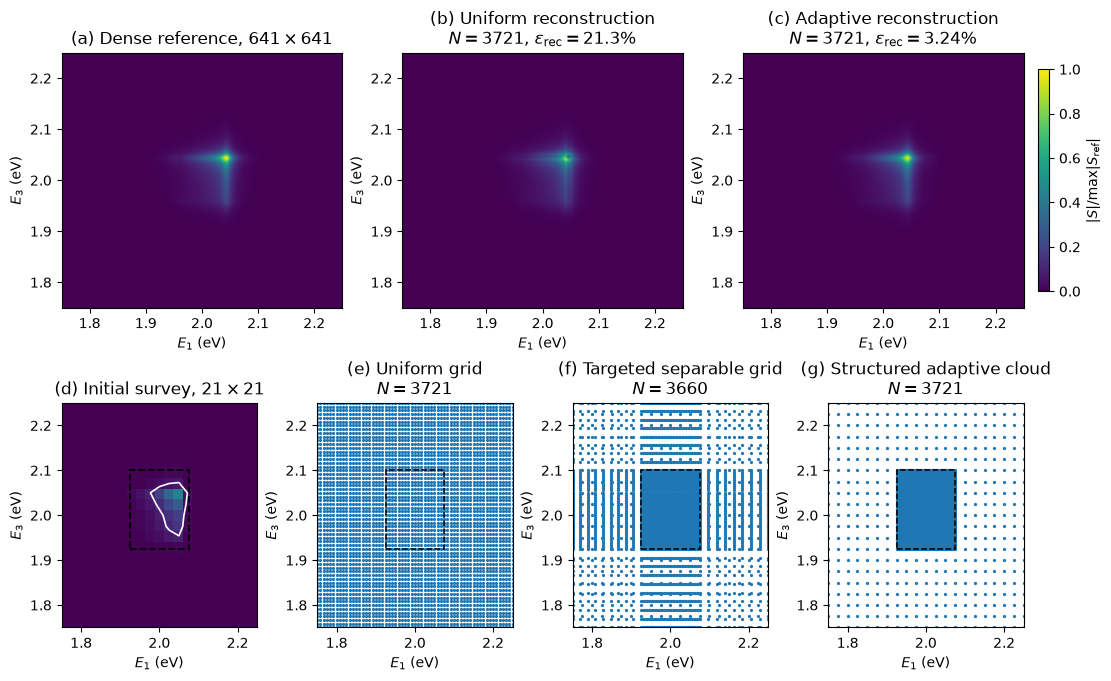

In [56]:
# ============================================================
# Figure 3 — Reconstruction and sampling strategies
# ============================================================

from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

fig = plt.figure(
    figsize=(11.0, 6.7),
    constrained_layout=True,
)

gs = GridSpec(
    2,
    12,
    figure=fig,
    height_ratios=[1.0, 0.88],
)

# Top row: three equal-width panels
ax_a = fig.add_subplot(gs[0, 0:4])
ax_b = fig.add_subplot(gs[0, 4:8])
ax_c = fig.add_subplot(gs[0, 8:12])

# Bottom row: four equal-width panels
ax_d = fig.add_subplot(gs[1, 0:3])
ax_e = fig.add_subplot(gs[1, 3:6])
ax_f = fig.add_subplot(gs[1, 6:9])
ax_g = fig.add_subplot(gs[1, 9:12])

extent = [
    E_min,
    E_max,
    E_min,
    E_max,
]


# ============================================================
# Top row — spectra
# ============================================================

im_amp = ax_a.imshow(
    A_reference,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax_a.set_title(
    r"(a) Dense reference, $641\times641$"
)

ax_b.imshow(
    A_uniform,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax_b.set_title(
    "(b) Uniform reconstruction\n"
    + rf"$N={S_uniform_fig3.size}$, "
    + rf"$\epsilon_{{\rm rec}}={100*err_uniform_fig3:.1f}\%$"
)

ax_c.imshow(
    A_adaptive,
    origin="lower",
    extent=extent,
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax_c.set_title(
    "(c) Adaptive reconstruction\n"
    + rf"$N={N_adaptive_fig3}$, "
    + rf"$\epsilon_{{\rm rec}}={100*err_adaptive_fig3:.2f}\%$"
)


# ============================================================
# Bottom row — sampling workflow
# ============================================================

# ------------------------------------------------------------
# (d) Initial survey
# ------------------------------------------------------------

ax_d.imshow(
    A_coarse,
    origin="lower",
    extent=extent,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

ax_d.contour(
    E1_coarse,
    E3_coarse,
    A_coarse,
    levels=[0.10],
    colors="white",
    linewidths=1.2,
)

ax_d.add_patch(
    Rectangle(
        (
            E1_target_min_timing,
            E3_target_min_timing,
        ),
        E1_target_max_timing
        - E1_target_min_timing,
        E3_target_max_timing
        - E3_target_min_timing,
        fill=False,
        linestyle="--",
        linewidth=1.3,
    )
)

ax_d.set_title(
    r"(d) Initial survey, $21\times21$"
)


# ------------------------------------------------------------
# Sampling-pattern helper
# ------------------------------------------------------------

def plot_sampling_pattern(
    ax,
    E1_points,
    E3_points,
    title,
    N_points,
):

    ax.scatter(
        E1_points,
        E3_points,
        s=1.7,
        rasterized=True,
    )

    ax.add_patch(
        Rectangle(
            (
                E1_target_min_timing,
                E3_target_min_timing,
            ),
            E1_target_max_timing
            - E1_target_min_timing,
            E3_target_max_timing
            - E3_target_min_timing,
            fill=False,
            linestyle="--",
            linewidth=1.1,
        )
    )

    ax.set_title(
        title
        + "\n"
        + rf"$N={N_points}$"
    )


plot_sampling_pattern(
    ax_e,
    E1_uniform_points,
    E3_uniform_points,
    "(e) Uniform grid",
    N_uniform_pattern,
)

plot_sampling_pattern(
    ax_f,
    E1_targeted_points,
    E3_targeted_points,
    "(f) Targeted separable grid",
    N_targeted_pattern,
)

plot_sampling_pattern(
    ax_g,
    E1_structured_points,
    E3_structured_points,
    "(g) Structured adaptive cloud",
    N_structured_pattern,
)


# ============================================================
# Axis formatting
# ============================================================

all_axes = [
    ax_a,
    ax_b,
    ax_c,
    ax_d,
    ax_e,
    ax_f,
    ax_g,
]

for ax in all_axes:

    ax.set_xlim(
        E_min,
        E_max,
    )

    ax.set_ylim(
        E_min,
        E_max,
    )

    ax.set_xlabel(
        r"$E_1$ (eV)"
    )

    ax.set_ylabel(
        r"$E_3$ (eV)"
    )


# ============================================================
# One shared spectrum colorbar
# ============================================================

cbar = fig.colorbar(
    im_amp,
    ax=[ax_a, ax_b, ax_c],
    shrink=0.87,
    pad=0.015,
)

cbar.set_label(
    r"$|S|/\max|S_{\rm ref}|$"
)

fig.savefig(
    figure_dir / "Figure03_targeted_frequency_sampling.pdf",
    bbox_inches="tight",
)

fig.savefig(
    figure_dir / "Figure03_targeted_frequency_sampling.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

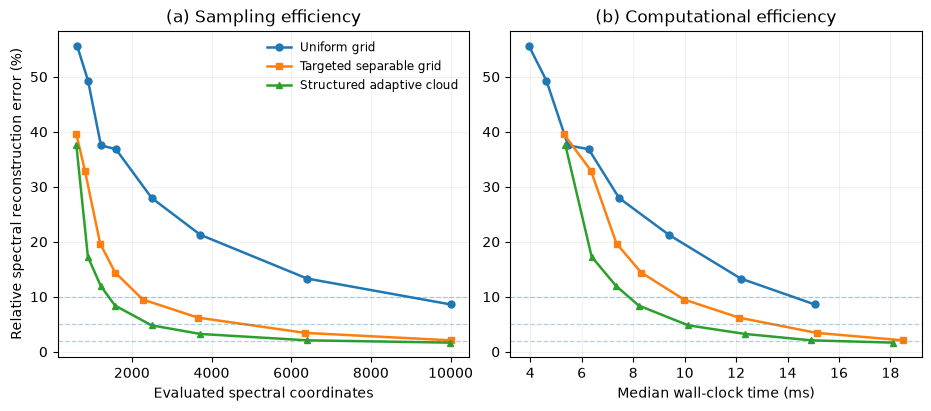

In [57]:
# ============================================================
# Figure 4 — Sampling and computational efficiency
# ============================================================

strategies = [
    ("uniform", "Uniform grid", "o"),
    ("targeted", "Targeted separable grid", "s"),
    ("structured", "Structured adaptive cloud", "^"),
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.2, 4.0),
    constrained_layout=True,
)

axN, axT = axes


# ------------------------------------------------------------
# (a) Reconstruction error vs evaluated coordinates
# ------------------------------------------------------------

for key, label, marker in strategies:

    N_values = np.array(
        [
            result["N"]
            for result in sampling_results[key]
        ],
        dtype=float,
    )

    errors = 100 * np.array(
        [
            result["global"]
            for result in sampling_results[key]
        ],
        dtype=float,
    )

    axN.plot(
        N_values,
        errors,
        marker=marker,
        linewidth=1.8,
        markersize=5,
        label=label,
    )


# ------------------------------------------------------------
# (b) Reconstruction error vs wall-clock time
# ------------------------------------------------------------

for key, label, marker in strategies:

    times_ms = np.array(
        [
            result["time_ms"]
            for result in timing_results[key]
        ],
        dtype=float,
    )

    errors = 100 * np.array(
        [
            result["global"]
            for result in timing_results[key]
        ],
        dtype=float,
    )

    axT.plot(
        times_ms,
        errors,
        marker=marker,
        linewidth=1.8,
        markersize=5,
        label=label,
    )


# ------------------------------------------------------------
# Threshold guides
# ------------------------------------------------------------

for ax in axes:

    for threshold in [10, 5, 2]:

        ax.axhline(
            threshold,
            linestyle="--",
            linewidth=0.9,
            alpha=0.35,
        )


# ------------------------------------------------------------
# Labels and titles
# ------------------------------------------------------------

axN.set_xlabel(
    "Evaluated spectral coordinates"
)

axT.set_xlabel(
    "Median wall-clock time (ms)"
)

axN.set_ylabel(
    "Relative spectral reconstruction error (%)"
)

axN.set_title(
    "(a) Sampling efficiency"
)

axT.set_title(
    "(b) Computational efficiency"
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

axN.legend(
    frameon=False,
    fontsize=8.5,
)


# ------------------------------------------------------------
# Light grid
# ------------------------------------------------------------

for ax in axes:

    ax.grid(
        True,
        alpha=0.18,
    )

fig.savefig(
    figure_dir / "Figure04_sampling_efficiency.pdf",
    bbox_inches="tight",
)

fig.savefig(
    figure_dir / "Figure04_sampling_efficiency.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [58]:
list(figure_dir.glob("*"))

[PosixPath('../figures/08_targeted_frequency_sampling/Figure03_targeted_frequency_sampling.png'),
 PosixPath('../figures/08_targeted_frequency_sampling/Figure03_targeted_frequency_sampling.pdf'),
 PosixPath('../figures/08_targeted_frequency_sampling/Figure04_sampling_efficiency.pdf'),
 PosixPath('../figures/08_targeted_frequency_sampling/Figure04_sampling_efficiency.png')]